In [ ]:
import subprocess, sys, torch
print(f"PyTorch: {torch.__version__}")
pkgs = [
    "fsspec==2024.9.0", "tqdm>=4.66.3", "datasets>=2.20.0",
    "accelerate>=0.30.0", "transformers>=4.44.0,<4.48.0",
    "sentence-transformers>=2.7.0,<3.0.0",
    "scikit-learn", "pandas", "numpy", "lightgbm", "statsmodels"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)
print("Установка завершена.")

PyTorch: 2.4.1+cu121


DEPRECATION: pytorch-lightning 1.6.4 has a non-standard dependency specifier torch>=1.8.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


Установка завершена.


## Шаг 1. Импорты, константы, GPU

In [2]:
import os, gc, pickle, warnings, math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from collections import Counter, defaultdict
from scipy.stats import entropy as scipy_entropy
from numpy.linalg import lstsq
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader as STDataLoader

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"
warnings.filterwarnings("ignore")

DATA_PATH  = "resumes_merged_filtered.csv"
MODEL_NAME = "intfloat/multilingual-e5-large"

CACHE_VERSION = "v20"  # v20: finetune titles-only, fixed baselines, million cities

CKPT_FT_A_R1  = "taskA_e5_ft_r1_v20"
CKPT_FT_A_R2  = "taskA_e5_ft_r2_v20"
CKPT_EMB_A    = f"taskA_embeddings_{CACHE_VERSION}.npz"
CKPT_META_A   = f"taskA_meta_{CACHE_VERSION}.pkl"
CKPT_STRUCT_A = f"taskA_struct_{CACHE_VERSION}.pkl"

FT_BATCH_R1 = 32; FT_BATCH_R2 = 32
FT_LR = 1e-5; FT_EPOCHS_R1 = 3; FT_EPOCHS_R2 = 1
# v18/v19: стратифицированная выборка вместо первых N
FT_R2_PAIRS = 8000; FT_R2_TOP_K = 5
FT_R2_SEED  = 99   # фиксированный seed для R2 subsampling

MLP_EPOCHS = 40; BATCH_SIZE = 128
DROPOUT_RATE = 0.3; WEIGHT_DECAY = 1e-4
PATIENCE = 8; MLP_HIDDEN = 256
LABEL_SMOOTHING = 0.1
N_FOLDS = 5

# v18: единые сиды для ablation и финального обучения
ABL_SEEDS = [42, 123, 777]
N_SEEDS_ABL = len(ABL_SEEDS)
MLP_KFOLD_SEEDS = ABL_SEEDS   # идентичны ablation seeds

# Task A: target = title_norm, история = job_3, job_2, job_1
TARGET_A         = "title_norm"
HIST_NORM_COLS_A = ["job_3_position_norm", "job_2_position_norm", "job_1_position_norm"]
HIST_DESC_COLS_A = ["job_3_description",   "job_2_description",   "job_1_description"]
JOB2_COL_A       = "job_1_position_norm"   # ближайшая предыдущая роль (для inertia/bigram)

DESC_MAX_CHARS = 500; SEP_TOKEN = " <SEP> "
TEST_SIZE = 0.15; VAL_FRAC = 0.10; RANDOM_SEED = 42
MIN_CLASS_SAMPLES = 50; EMB_DIM = 1024
SKIP = {"Other", "None", "nan", "NaN", "", "none", "null"}

N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 0
CI_LEVEL = 0.95

HAS_CUDA = torch.cuda.is_available()
def pick_free_gpu():
    if not HAS_CUDA: return None
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        free  = (props.total_memory - torch.cuda.memory_reserved(i)) / 1024**2
        print(f"  GPU {i} ({props.name}): free≈{free:.0f}MB")
        if free > best_free: best_free, best_idx = free, i
    return best_idx

if HAS_CUDA:
    gpu_idx = pick_free_gpu()
    device  = torch.device(f"cuda:{gpu_idx}")
    torch.cuda.set_device(gpu_idx)
    print(f"Device: {device} — {torch.cuda.get_device_name(gpu_idx)}")
else:
    device = torch.device("cpu")
    print("Device: cpu")

def _gc():
    gc.collect()
    if HAS_CUDA: torch.cuda.empty_cache()

print(f"CACHE_VERSION={CACHE_VERSION}")
print(f"Target: {TARGET_A}  |  История: {HIST_NORM_COLS_A}")


/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


  GPU 0 (NVIDIA A100 80GB PCIe): free≈81038MB
Device: cuda:0 — NVIDIA A100 80GB PCIe
CACHE_VERSION=v20
Target: title_norm  |  История: ['job_3_position_norm', 'job_2_position_norm', 'job_1_position_norm']


## Шаг 2. Загрузка данных и сплит Task A

In [3]:
df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Всего строк: {len(df_full)}")

# ── Task A: фильтрация по target ──────────────────────────────────────────────
labeled_A = ~df_full[TARGET_A].fillna("None").isin(SKIP)
df_A_pre  = df_full[labeled_A].reset_index(drop=True)
y_A_pre   = df_A_pre[TARGET_A].fillna("").astype(str).values

count_A = Counter(y_A_pre)
valid_A = {r for r, c in count_A.items() if c >= max(MIN_CLASS_SAMPLES, 2)}
mask_A  = np.array([y in valid_A for y in y_A_pre])
df_A    = df_A_pre[mask_A].reset_index(drop=True)
y_A     = df_A[TARGET_A].fillna("").astype(str).values
print(f"После фильтрации по vocab: {len(df_A)} строк")

# Фильтр: должна быть хотя бы одна запись из истории (job_1 обязателен)
# Task A предсказывает title_norm, поэтому история — job_3, job_2, job_1
# job_1_position_norm — ближайшая предыдущая роль, она должна быть
has_history = [
    any(str(df_A.iloc[i].get(c, "") or "").strip() not in SKIP
        for c in HIST_NORM_COLS_A)
    for i in range(len(df_A))
]
df_A = df_A[has_history].reset_index(drop=True)
y_A  = df_A[TARGET_A].fillna("").astype(str).values
print(f"После фильтра истории: {len(df_A)} строк")

# ── Сплит ─────────────────────────────────────────────────────────────────────
idx_all_A = np.arange(len(df_A))
idx_tv_A, idx_te_A = train_test_split(
    idx_all_A, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_A)
idx_tr_A, idx_vl_A = train_test_split(
    idx_tv_A, test_size=VAL_FRAC, random_state=RANDOM_SEED, stratify=y_A[idx_tv_A])

train_counts_A = Counter(y_A[idx_tr_A])
all_roles_A    = sorted(r for r, c in train_counts_A.items() if c >= MIN_CLASS_SAMPLES)
role_to_id_A   = {r: i for i, r in enumerate(all_roles_A)}
id_to_role_A   = {i: r for r, i in role_to_id_A.items()}
VOCAB_A        = len(all_roles_A)

def keep_A(idx):
    return np.array([i for i in idx if y_A[i] in role_to_id_A], dtype=np.int64)
idx_tr_A = keep_A(idx_tr_A); idx_vl_A = keep_A(idx_vl_A); idx_te_A = keep_A(idx_te_A)
idx_tv_A = np.concatenate([idx_tr_A, idx_vl_A])
y_tr_A = np.array([role_to_id_A[y_A[i]] for i in idx_tr_A])
y_vl_A = np.array([role_to_id_A[y_A[i]] for i in idx_vl_A])
y_te_A = np.array([role_to_id_A[y_A[i]] for i in idx_te_A])
y_tv_A = np.concatenate([y_tr_A, y_vl_A])

with open(CKPT_META_A, "wb") as f:
    pickle.dump(dict(
        idx_tr=idx_tr_A, idx_vl=idx_vl_A, idx_te=idx_te_A, idx_tv=idx_tv_A,
        y_tr=y_tr_A, y_vl=y_vl_A, y_te=y_te_A, y_tv=y_tv_A,
        role_to_id=role_to_id_A, id_to_role=id_to_role_A,
        VOCAB_SIZE=VOCAB_A, all_roles=all_roles_A), f)

print(f"Task A vocab: {VOCAB_A} классов")
print(f"Train={len(idx_tr_A)}, Val={len(idx_vl_A)}, Test={len(idx_te_A)}")
print(f"История: {HIST_NORM_COLS_A}")

Всего строк: 111869
После фильтрации по vocab: 111661 строк
После фильтра истории: 108731 строк
Task A vocab: 38 классов
Train=83062, Val=9231, Test=16288
История: ['job_3_position_norm', 'job_2_position_norm', 'job_1_position_norm']


## Шаг 3. Построение документов (doc_car, doc_occ)

In [4]:
def build_doc_car_desc(row, norm_cols, desc_cols):
    parts = []
    for nc, dc in zip(norm_cols, desc_cols):
        p = str(row.get(nc, "") or "").strip()
        d = str(row.get(dc, "") or "").strip()[:DESC_MAX_CHARS]
        if p and p not in SKIP:
            parts.append(f"role: {p}\ndescription: {d}" if d and len(d) > 20 else f"role: {p}")
    return ("query: " + SEP_TOKEN.join(parts)) if parts else None

def build_doc_car_titles(row, norm_cols):
    parts = []
    for nc in norm_cols:
        p = str(row.get(nc, "") or "").strip()
        if p and p not in SKIP: parts.append(f"role: {p}")
    return ("query: " + SEP_TOKEN.join(parts)) if parts else None

def build_doc_occ(role_name):
    return f"passage: role: {role_name}"

N_A = len(df_A)
docs_titles_A = [build_doc_car_titles(df_A.iloc[i], HIST_NORM_COLS_A) for i in range(N_A)]
docs_desc_A   = [build_doc_car_desc(df_A.iloc[i], HIST_NORM_COLS_A, HIST_DESC_COLS_A) for i in range(N_A)]
print(f"doc_car_titles: {sum(1 for d in docs_titles_A if d)}/{N_A}")
print(f"doc_car_desc:   {sum(1 for d in docs_desc_A if d)}/{N_A}")

doc_car_titles: 108731/108731
doc_car_desc:   108731/108731


## Шаг 4. Структурные признаки

In [5]:
if os.path.isfile(CKPT_STRUCT_A):
    with open(CKPT_STRUCT_A, "rb") as f:
        sc = pickle.load(f)
    X_career_A   = sc["X_career"]
    X_location_A = sc["X_location"]
    X_edu_A      = sc["X_edu"]
    print("Структурные признаки загружены из кэша.")
else:
    # Task A: история job_3, job_2, job_1 → три длительности + опыт
    raw_cols = ["experience_count", "job_1_duration_months",
                "job_2_duration_months", "job_3_duration_months"]
    df_num = df_A[raw_cols].copy().fillna(df_A[raw_cols].iloc[idx_tr_A].median())

    def get_career_stats(row_s):
        exp   = float(row_s["experience_count"])
        d1    = float(row_s["job_1_duration_months"])
        d2    = float(row_s["job_2_duration_months"])
        d3    = float(row_s["job_3_duration_months"])
        total = d1 + d2 + d3
        depth = exp * math.log1p(total)
        # tenure = длина текущей роли (job_1 в Task A) — сигнал готовности к переходу
        tenure_log = math.log1p(d1)
        return [exp, total, d1, depth, tenure_log]

    career_raw = np.array(
        [get_career_stats(df_num.iloc[i]) for i in range(N_A)], dtype=np.float32)
    scaler_c = StandardScaler(); scaler_c.fit(career_raw[idx_tr_A])
    X_career_A = scaler_c.transform(career_raw).astype(np.float32)

    # v20: 4 метки — Москва / Питер / Миллионники (ЕКБ, НСК, КЗН, НН, ЧЛ, СМ, УФА, РСТ, КРС, ВРН, ПРМ, ВЛГ) / Другие
    MILLION_CITIES_KW = [
        "екатеринб", "yekaterinb", "ekaterinb", "екб",
        "новосибирск", "novosibirsk", "нск",
        "казан", "kazan",
        "нижн", "nizhny", "nnov",
        "челябинск", "chelyabinsk",
        "самар", "samara",
        "уфа", "ufa",
        "ростов", "rostov",
        "красноярск", "krasnoyarsk",
        "воронеж", "voronezh",
        "пермь", "perm",
        "волгоград", "volgograd",
    ]
    def get_location(row):
        loc = str(row.get("location", "") or "").lower().strip()
        if "москв" in loc or "moscow" in loc:
            return [1, 0, 0, 0]
        elif "петерб" in loc or "peter" in loc or "ленингр" in loc or "spb" in loc:
            return [0, 1, 0, 0]
        elif any(city in loc for city in MILLION_CITIES_KW):
            return [0, 0, 1, 0]
        else:
            return [0, 0, 0, 1]
    X_location_A = np.array(
        [get_location(df_A.iloc[i]) for i in range(N_A)], dtype=np.float32)

    edu_med = float(df_A["education_level"].iloc[idx_tr_A].median())
    def get_edu(row):
        lv = float(row.get("education_level") or edu_med)
        return [(edu_med if math.isnan(lv) else lv - 2) / 3.0]
    X_edu_A = np.array(
        [get_edu(df_A.iloc[i]) for i in range(N_A)], dtype=np.float32)

    with open(CKPT_STRUCT_A, "wb") as f:
        pickle.dump(dict(X_career=X_career_A, X_location=X_location_A, X_edu=X_edu_A), f)
    print("Структурные признаки сохранены.")

# v18: структурные признаки стандартизированы по обучающей выборке (z-score);
# бинарные признаки географии оставлены без дополнительного масштабирования.
# STRUCT_ALPHA убран (как в Task B v14).
X_career_A_sc   = X_career_A
X_location_A_sc = X_location_A
X_edu_A_sc      = X_edu_A
print(f"career={X_career_A.shape}, location={X_location_A.shape}, edu={X_edu_A.shape}")


Структурные признаки загружены из кэша.
career=(108731, 5), location=(108731, 4), edu=(108731, 1)


## Шаг 5. Fine-tuning энкодера — стратегия LAST

Пары `(job_3 + job_2 + job_1 → title_norm)`.  
Валидационная выборка (`idx_vl_A`) используется только для early stopping MLP и выбора конфигурации — но **не** для обучения энкодера.  
R2 hard negatives: стратифицированная случайная выборка по классам.  
Class-aware batching для MNRL: батчи формируются без дублей label → нет ложных in-batch negatives.


In [6]:
def build_finetune_pairs_LAST(row, use_desc=True):
    """
    LAST стратегия (Decorte et al. 2023, Senger et al. 2025).
    v18: вызывается только для idx_tr_A (без val).
    v20: use_desc=False — fine-tuning только на должностях. Иначе энкодер "съедает" структуру описаний
         до ablation, занижая вклад X_doc и завышая вклад X_skills_emb / X_about_emb.
    """
    parts = []
    for nc, dc in zip(HIST_NORM_COLS_A, HIST_DESC_COLS_A):
        p = str(row.get(nc, "") or "").strip()
        d = str(row.get(dc, "") or "").strip()[:DESC_MAX_CHARS]
        if p and p not in SKIP:
            parts.append(f"role: {p}\ndescription: {d}" if (use_desc and d and len(d) > 20)
                         else f"role: {p}")
    if not parts:
        return []
    target = str(row.get(TARGET_A, "") or "").strip()
    if not target or target in SKIP:
        return []
    query = "query: " + SEP_TOKEN.join(parts)
    return [(query, build_doc_occ(target))]


def make_class_aware_dataloader(pairs, role_to_id, batch_size, shuffle_seed=42):
    """
    Class-aware DataLoader для MNRL: батч формируется без дублей target label.
    Это предотвращает ложные in-batch negatives.
    При batch_size > VOCAB_A дублей не избежать — в этом случае fallback к обычному shuffle.
    """
    import random

    vocab_size = len(role_to_id)
    if batch_size >= vocab_size:
        print(f"  ⚠ batch_size={batch_size} >= vocab_size={vocab_size}: "
              f"class-aware batching невозможен, используем обычный shuffle.")
        examples = [InputExample(texts=[a, p]) for a, p in pairs]
        return STDataLoader(examples, shuffle=True, batch_size=batch_size)

    # Группируем пары по label
    label_to_pairs = defaultdict(list)
    for a, p in pairs:
        role = p.replace("passage: role: ", "").strip()
        if role in role_to_id:
            label_to_pairs[role_to_id[role]].append((a, p))

    rng = random.Random(shuffle_seed)
    labels = list(label_to_pairs.keys())
    rng.shuffle(labels)

    queues = {lbl: list(pairs_list) for lbl, pairs_list in label_to_pairs.items()}
    for q in queues.values():
        rng.shuffle(q)

    batches = []
    while True:
        available = [lbl for lbl in labels if queues[lbl]]
        if len(available) < batch_size // 2:
            break
        rng.shuffle(available)
        batch_labels = available[:batch_size]
        batch_pairs = []
        for lbl in batch_labels:
            pair = queues[lbl].pop()
            batch_pairs.append(pair)
        batches.append(batch_pairs)

    all_examples = [InputExample(texts=[a, p]) for batch in batches for a, p in batch]
    print(f"  Class-aware batching: {len(batches)} батчей × {batch_size}, "
          f"{len(all_examples)} примеров из {len(pairs)} пар")
    return STDataLoader(all_examples, shuffle=False, batch_size=batch_size)


def run_finetune_r1(model_path, pairs, role_to_id, batch_size, lr, epochs, save_path):
    """R1: class-aware batching для MNRL."""
    if os.path.isdir(save_path):
        print(f"Загружаю чекпоинт: {save_path}")
        return SentenceTransformer(save_path, device=str(device))
    print(f"Fine-tuning R1 → {save_path}  ({len(pairs)} пар, epochs={epochs})")
    st = SentenceTransformer(model_path, device=str(device))
    ld = make_class_aware_dataloader(pairs, role_to_id, batch_size)
    loss_fn = losses.MultipleNegativesRankingLoss(st)
    st.fit(
        train_objectives=[(ld, loss_fn)],
        epochs=epochs,
        warmup_steps=int(len(ld) * epochs * 0.1),
        optimizer_params={"lr": lr},
        show_progress_bar=True,
        output_path=save_path,
        save_best_model=True,
        use_amp=True,
    )
    return SentenceTransformer(save_path, device=str(device))


# v18: строим пары LAST только на idx_tr_A (без val)
print("Строим пары LAST (job_3+job_2+job_1 → title_norm) только на idx_tr_A...")
train_pairs_A = []
for i in idx_tr_A:
    train_pairs_A.extend(build_finetune_pairs_LAST(df_A.iloc[i], use_desc=False))  # v20: только должности
print(f"Пар для R1 (LAST, train only): {len(train_pairs_A)}")

st_r1 = run_finetune_r1(MODEL_NAME, train_pairs_A, role_to_id_A,
                         FT_BATCH_R1, FT_LR, FT_EPOCHS_R1, CKPT_FT_A_R1)
_gc()
print("R1 готов.")


Строим пары LAST (job_3+job_2+job_1 → title_norm) только на idx_tr_A...
Пар для R1 (LAST, train only): 83062
Загружаю чекпоинт: taskA_e5_ft_r1_v20
R1 готов.


In [7]:
if os.path.isdir(CKPT_FT_A_R2):
    print(f"Загружаю R2: {CKPT_FT_A_R2}")
    st_r2 = SentenceTransformer(CKPT_FT_A_R2, device=str(device))
else:
    print("Генерирую hard negatives для Task A (v18: stratified subsampling)...")
    role_texts_A  = [build_doc_occ(r) for r in all_roles_A]
    role_emb_r1_A = st_r1.encode(role_texts_A, batch_size=32,
                                  normalize_embeddings=True, show_progress_bar=False)

    # v18: стратифицированная выборка по классам вместо первых N пар
    rng_r2 = np.random.default_rng(FT_R2_SEED)
    # Группируем индексы train_pairs_A по label
    label_to_indices = defaultdict(list)
    for idx_pair, (a, p) in enumerate(train_pairs_A):
        role = p.replace("passage: role: ", "").strip()
        if role in role_to_id_A:
            label_to_indices[role_to_id_A[role]].append(idx_pair)

    # Stratified sample: берём равномерно из каждого класса
    n_classes = len(label_to_indices)
    n_per_class = max(1, FT_R2_PAIRS // n_classes)
    r2_indices = []
    for lbl, idxs in label_to_indices.items():
        chosen = rng_r2.choice(idxs, size=min(n_per_class, len(idxs)), replace=False)
        r2_indices.extend(chosen.tolist())
    rng_r2.shuffle(r2_indices)
    r2_indices = r2_indices[:FT_R2_PAIRS]
    print(f"  R2 stratified sample: {len(r2_indices)} пар из {len(train_pairs_A)} "
          f"({n_classes} классов, ~{n_per_class} на класс)")

    anc_txts = [train_pairs_A[j][0] for j in r2_indices]
    pos_txts = [train_pairs_A[j][1] for j in r2_indices]
    anc_embs = st_r1.encode(anc_txts, batch_size=FT_BATCH_R2,
                              normalize_embeddings=True, show_progress_bar=True)
    scores_all = (torch.tensor(anc_embs) @ torch.tensor(role_emb_r1_A).T).numpy()

    hard_examples = []
    for j, (anc, pos_txt) in enumerate(zip(anc_txts, pos_txts)):
        pos_role = pos_txt.replace("passage: role: ", "").strip()
        if pos_role not in role_to_id_A: continue
        pos_id = role_to_id_A[pos_role]
        row_scores = scores_all[j].copy(); row_scores[pos_id] = -2.0
        top_k = np.argsort(row_scores)[::-1][:FT_R2_TOP_K]
        hard_examples.append(InputExample(
            texts=[anc, pos_txt] + [build_doc_occ(all_roles_A[k]) for k in top_k]))

    st_r1.to("cpu"); _gc()
    st_r2   = SentenceTransformer(CKPT_FT_A_R1, device=str(device))
    ld_r2   = STDataLoader(hard_examples, shuffle=True, batch_size=FT_BATCH_R2)
    loss_r2 = losses.MultipleNegativesRankingLoss(st_r2)
    st_r2.fit(train_objectives=[(ld_r2, loss_r2)], epochs=FT_EPOCHS_R2,
              warmup_steps=int(len(ld_r2)*0.1), optimizer_params={"lr": FT_LR},
              show_progress_bar=True, output_path=CKPT_FT_A_R2, save_best_model=True,
              use_amp=True)
_gc(); print("R2 готов.")


Загружаю R2: taskA_e5_ft_r2_v20
R2 готов.


## Шаг 6. Кодирование эмбеддингов

In [8]:
# ── Безопасная проверка кэша (BadZipFile если файл повреждён) ────────────────
def _load_emb_cache(path):
    """Загружает .npz кэш. Возвращает dict или None если файл отсутствует/повреждён."""
    if not os.path.isfile(path):
        return None
    try:
        data = np.load(path, allow_pickle=False)
        if "X_about_emb" not in data:
            print(f"Кэш {path} устарел (нет X_about_emb) — пересчитываю.")
            return None
        return dict(data)
    except Exception as e:
        print(f"Кэш {path} повреждён ({type(e).__name__}: {e}) — пересчитываю.")
        os.remove(path)  # удаляем битый файл
        return None

feats = _load_emb_cache(CKPT_EMB_A)
if feats is None:
    print(f"Кодирую → {CKPT_EMB_A}")
    st = SentenceTransformer(CKPT_FT_A_R2, device=str(device))
    def enc(texts, bs=32):
        safe = [t if t is not None else "query: [empty]" for t in texts]
        return st.encode(safe, batch_size=bs, normalize_embeddings=True,
                         show_progress_bar=True).astype(np.float32)

    role_texts  = [build_doc_occ(r) for r in all_roles_A]
    role_emb_np = st.encode(role_texts, batch_size=32, normalize_embeddings=True,
                             show_progress_bar=False).astype(np.float32)
    X_seq = enc(docs_titles_A, bs=32)
    X_doc = enc(docs_desc_A,   bs=16)

    def build_skills_text(row):
        s = str(row.get("skills", "") or "").strip()
        return ("query: skills: " + s) if s else "query: skills: [empty]"
    docs_skills = [build_skills_text(df_A.iloc[i]) for i in range(N_A)]
    X_skills_emb = enc(docs_skills, bs=16)

    def build_about_text(row):
        a = str(row.get("about", "") or "").strip()
        return ("query: about: " + a[:500]) if a else "query: about: [empty]"
    docs_about = [build_about_text(df_A.iloc[i]) for i in range(N_A)]
    X_about_emb = enc(docs_about, bs=16)

    st.to("cpu"); _gc()
    np.savez_compressed(CKPT_EMB_A,
        role_emb=role_emb_np, X_seq=X_seq, X_doc=X_doc,
        X_skills_emb=X_skills_emb, X_about_emb=X_about_emb)
    feats = dict(np.load(CKPT_EMB_A, allow_pickle=False))
    print(f"Закодировано и сохранено: {CKPT_EMB_A}")
else:
    print(f"Загружено из кэша: {CKPT_EMB_A}")

role_emb    = torch.tensor(feats["role_emb"]).float()
role_emb_np = role_emb.numpy()
print(f"role_emb: {role_emb.shape}")
print(f"X_seq: {feats['X_seq'].shape}, X_doc: {feats['X_doc'].shape}")
print(f"X_skills_emb: {feats['X_skills_emb'].shape}, X_about_emb: {feats['X_about_emb'].shape}")

Загружено из кэша: taskA_embeddings_v20.npz
role_emb: torch.Size([38, 1024])
X_seq: (108731, 1024), X_doc: (108731, 1024)
X_skills_emb: (108731, 1024), X_about_emb: (108731, 1024)


## Шаг 7. Метрики и baselines

In [9]:
def eval_full(scores, y_true):
    order = np.argsort(-scores, axis=1)
    ranks = np.where(order == y_true[:, None])[1] + 1
    return {"MRR": float(np.mean(1.0/ranks)), "R@1": float(np.mean(ranks<=1)),
            "R@3": float(np.mean(ranks<=3)),  "R@5": float(np.mean(ranks<=5))}

def fmt(res):
    return (f"MRR={res['MRR']*100:.2f}%  R@1={res['R@1']*100:.2f}%  "
            f"R@3={res['R@3']*100:.2f}%  R@5={res['R@5']*100:.2f}%")

# ── Baselines ─────────────────────────────────────────────────────────────────
train_cnt  = Counter(y_tr_A.tolist())

# v20: Majority = Global Popularity Ranking
# Scores = частота класса → argsort(-s) даёт правильный порядок: rank 1 = самый частый, rank 2 = второй...
major_freqs = np.array([train_cnt.get(i, 0) for i in range(VOCAB_A)], dtype=np.float32)

def majority_scores(n):
    """
    Каждой строке присваивается одинаковый вектор частот.
    argsort(-s) → rank 1: наиболее частый класс, rank 2: второй по частоте, ...
    """
    return np.tile(major_freqs, (n, 1))

# v20: Inertia = Previous Role First
# rank 1 = предыдущая должность (если известна), иначе most-frequent
# хвост (ranks 2..K) заполнен по убыванию частоты (как в Majority)
def inertia_scores(indices):
    """
    R@1 = доля случаев, где job_1 == title_norm (инерция).
    R@5 > R@1 потому что tail ranks заполнены популярными классами.
    """
    s = np.tile(major_freqs, (len(indices), 1))
    max_score = float(major_freqs.max()) + 1.0
    for j, i in enumerate(indices):
        prev = str(df_A.iloc[i].get(JOB2_COL_A, "") or "").strip()
        if prev in role_to_id_A:
            s[j, role_to_id_A[prev]] = max_score
    return s

job2_vals = sorted(set(df_A[JOB2_COL_A].fillna("None").values) - SKIP)
j2i = {r: ii for ii, r in enumerate(job2_vals)}
cnt_mat = np.ones((len(job2_vals), VOCAB_A), dtype=np.float32)
for pos, i in enumerate(idx_tr_A):
    t  = y_A[i]; j2 = str(df_A.iloc[i].get(JOB2_COL_A, "") or "").strip()
    if t in role_to_id_A and j2 in j2i:
        cnt_mat[j2i[j2], role_to_id_A[t]] += 1
prior_mat = cnt_mat / cnt_mat.sum(axis=1, keepdims=True)

def bigram_scores(indices):
    s = np.zeros((len(indices), VOCAB_A), dtype=np.float32)
    unif = np.ones(VOCAB_A, dtype=np.float32) / VOCAB_A
    for j, i in enumerate(indices):
        j2 = str(df_A.iloc[i].get(JOB2_COL_A, "") or "").strip()
        s[j] = prior_mat[j2i[j2]] if j2 in j2i else unif
    return s

expected_random_mrr = sum(1.0/k for k in range(1, VOCAB_A+1)) / VOCAB_A

print("BASELINES (Task A: title_norm):")
print(f"  Majority  = Global Popularity Ranking (rank 1: most freq class, остальные по убыванию частоты)")
print(f"  Inertia   = Previous Role First (rank 1: job_1_position_norm, хвост: по частоте)")
print(f"  Bigram    = p(next|prev) с Лапласовским сглаживанием")
print(f"  Random (теор.) MRR ≈ {expected_random_mrr*100:.2f}%")
res_baselines = {}
for name, sc in [("Majority",    majority_scores(len(y_te_A))),
                 ("Inertia",     inertia_scores(idx_te_A)),
                 ("Bigram prior",bigram_scores(idx_te_A))]:
    res_baselines[name] = eval_full(sc, y_te_A)
    print(f"  {name:<14s}: {fmt(res_baselines[name])}")


BASELINES (Task A: title_norm):
  Majority  = Global Popularity Ranking (rank 1: most freq class, остальные по убыванию частоты)
  Inertia   = Previous Role First (rank 1: job_1_position_norm, хвост: по частоте)
  Bigram    = p(next|prev) с Лапласовским сглаживанием
  Random (теор.) MRR ≈ 11.13%
  Majority      : MRR=36.26%  R@1=18.23%  R@3=43.31%  R@5=59.31%
  Inertia       : MRR=58.91%  R@1=46.59%  R@3=65.94%  R@5=73.72%
  Bigram prior  : MRR=55.50%  R@1=43.74%  R@3=60.04%  R@5=67.74%


## Шаг 8. Linear Projection (Senger et al. baseline)

In [10]:
def train_linear(X_tr, y_tr_):
    Tt, _, _, _ = lstsq(X_tr, role_emb_np[y_tr_], rcond=None); return Tt

def predict_linear(Tt, X):
    proj = X @ Tt
    return (proj / np.linalg.norm(proj, axis=1, keepdims=True).clip(1e-8)) @ role_emb_np.T

results_linear = {}
for cfg_name, feat_key in [("Linear — titles only", "X_seq"),
                            ("Linear — with desc",   "X_doc")]:
    X_all = feats[feat_key]
    Tt    = train_linear(X_all[idx_tr_A], y_tr_A)
    sc_te = predict_linear(Tt, X_all[idx_te_A])
    results_linear[cfg_name] = {
        "val":  eval_full(predict_linear(Tt, X_all[idx_vl_A]), y_vl_A),
        "test": eval_full(sc_te, y_te_A), "scores_te": sc_te,
    }
    print(f"{cfg_name}: {fmt(results_linear[cfg_name]['test'])}")

Linear — titles only: MRR=65.24%  R@1=52.51%  R@3=73.75%  R@5=80.27%
Linear — with desc: MRR=68.64%  R@1=55.31%  R@3=78.27%  R@5=85.35%


## Шаг 9. CareerMLP — два варианта архитектуры

### v18: Additive (финальная модель) vs Gated (только routing analysis)

**Протокол ablation (retrain)**: каждая конфигурация обучается заново с нуля на 3 seeds.  
Это retrain-ablation: маржинальный вклад признака оценивается как разность MRR между двумя  
конфигурациями, каждая из которых обучена независимо.  
*(Примечание: при retrain-ablation веса модели адаптируются к каждому набору признаков,  
поэтому результат отражает предсказательную ценность признака при совместном обучении,  
а не sensitivity при фиксированных весах.)*

**Gate-анализ**: среднее softmax-gate ≠ feature importance.  
Среднее `ḡ_k` отражает среднюю долю ветви в финальном векторе, но не information gain.  
Используется только как диагностика routing, не как доказательство важности признаков.


In [11]:
# ── Temperature инициализация ─────────────────────────────────────────────────
def _init_log_temp(vocab_size):
    """log(1 / sqrt(VOCAB)) — правильная инициализация для contrastive."""
    return math.log(1.0 / math.sqrt(max(vocab_size, 1)))

class CareerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X); self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# ══════════════════════════════════════════════════════════════════════════════
# v18-additive: чистый ablation через обнуление слагаемого
# ══════════════════════════════════════════════════════════════════════════════
class CareerMLP_Additive(nn.Module):
    """
    Additive fusion (v18 Task A = v14 Task B):
    Ablation = обнуление слагаемого, веса остальных ветвей не меняются.
    """
    def __init__(self, input_dim, hidden_dim=MLP_HIDDEN, dropout=DROPOUT_RATE,
                 emb_dim=EMB_DIM, vocab_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim); self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dr1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.dr2 = nn.Dropout(dropout * 0.7)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim//2); self.bn3 = nn.BatchNorm1d(hidden_dim//2)
        self.dr3 = nn.Dropout(dropout * 0.5)
        self.out = nn.Linear(hidden_dim//2, emb_dim)
        self.log_temp = nn.Parameter(torch.tensor(_init_log_temp(vocab_size)))

    def _encode(self, x):
        h = self.dr1(F.relu(self.bn1(self.fc1(x))))
        h = h + self.dr2(F.relu(self.bn2(self.fc2(h))))
        h = self.dr3(F.relu(self.bn3(self.fc3(h))))
        return self.out(h)

    def forward(self, x):
        return F.normalize(self._encode(x), p=2, dim=1)

    def temperature(self):
        return self.log_temp.exp().clamp(0.01, 1.0).item()


# ══════════════════════════════════════════════════════════════════════════════
# v18-gated: 3 независимых энкодера + softmax gate (learned per-sample)
# ══════════════════════════════════════════════════════════════════════════════
class CareerMLP_Gated(nn.Module):
    """
    Gated fusion (v18 Task A = v14 Task B):
        g = softmax( gate_net(x) )  — scalar gate per branch, per sample
        hi = encode_i(xi)            — branch-specific encoders
    out = L2_norm( sum_i g_i * proj_i(hi) )
    """
    def __init__(self, dims, hidden_dim=MLP_HIDDEN, dropout=DROPOUT_RATE,
                 emb_dim=EMB_DIM, vocab_size=1):
        super().__init__()
        assert len(dims) == 3, "Gated fusion requires exactly 3 branches"
        self.dims = dims
        total_dim = sum(dims)

        def _branch(d):
            return nn.Sequential(
                nn.Linear(d, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2), nn.ReLU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(hidden_dim//2, emb_dim),
            )

        self.enc1 = _branch(dims[0])
        self.enc2 = _branch(dims[1])
        self.enc3 = _branch(dims[2])

        self.gate = nn.Sequential(
            nn.Linear(total_dim, hidden_dim//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 3),
        )
        self.log_temp = nn.Parameter(torch.tensor(_init_log_temp(vocab_size)))

    def forward(self, x, return_gates=False):
        d0, d1, d2 = self.dims
        x1 = x[:, :d0]
        x2 = x[:, d0:d0+d1]
        x3 = x[:, d0+d1:]

        g = F.softmax(self.gate(x), dim=1)  # (B, 3)
        h1 = self.enc1(x1); h2 = self.enc2(x2); h3 = self.enc3(x3)
        out = g[:, 0:1] * h1 + g[:, 1:2] * h2 + g[:, 2:3] * h3
        out = F.normalize(out, p=2, dim=1)

        if return_gates:
            return out, g.detach().cpu()
        return out

    def temperature(self):
        return self.log_temp.exp().clamp(0.01, 1.0).item()


# ── train / predict универсальные ─────────────────────────────────────────────
def predict_mlp(model, X, re_tensor, batch_size=BATCH_SIZE):
    model.eval(); rd = re_tensor.to(device)
    ld = DataLoader(CareerDataset(X, np.zeros(len(X), dtype=np.int64)), batch_size=batch_size)
    sc = []
    with torch.no_grad():
        for Xb, _ in ld:
            t = model.log_temp.exp().clamp(0.01, 1.0)
            out = model(Xb.to(device))
            sc.append(((out @ rd.T) / t).cpu().numpy())
    return np.concatenate(sc, axis=0)

def train_mlp(model, X_tr, y_tr_, X_vl, y_vl_, re_tensor,
              epochs=MLP_EPOCHS, patience=PATIENCE, lr=3e-4, verbose=False):
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5, min_lr=1e-5)
    rd    = re_tensor.to(device)
    crit  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    trl   = DataLoader(CareerDataset(X_tr, y_tr_), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    vll   = DataLoader(CareerDataset(X_vl, y_vl_), batch_size=BATCH_SIZE)
    best_loss = float("inf")
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    no_imp = 0

    for ep in range(epochs):
        model.train(); tl = 0.0
        for Xb, yb in trl:
            Xb, yb = Xb.to(device), yb.to(device)
            model.log_temp.data.clamp_(math.log(0.01), math.log(1.0))
            loss = crit((model(Xb) @ rd.T) / model.log_temp.exp(), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item()
        model.eval(); vl = 0.0
        with torch.no_grad():
            for Xb, yb in vll:
                Xb, yb = Xb.to(device), yb.to(device)
                vl += crit((model(Xb) @ rd.T) / model.log_temp.exp(), yb).item()
        vl /= max(len(vll), 1); sched.step(vl)
        if verbose: print(f"  Ep{ep+1:2d}: tr={tl/len(trl):.4f} val={vl:.4f} T={model.temperature():.4f}")
        if vl < best_loss:
            best_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience: break
    model.load_state_dict(best_state)
    return model

def norm_scores(sc):
    mn = sc.min(axis=1, keepdims=True); mx = sc.max(axis=1, keepdims=True)
    return (sc - mn) / (mx - mn + 1e-9)

print(f"CareerMLP_Additive и CareerMLP_Gated определены.")
print(f"Temperature clamp: [0.01, 1.0], init=log(1/sqrt(VOCAB_A))")
print(f"label_smoothing={LABEL_SMOOTHING}, N_FOLDS={N_FOLDS}")


CareerMLP_Additive и CareerMLP_Gated определены.
Temperature clamp: [0.01, 1.0], init=log(1/sqrt(VOCAB_A))
label_smoothing=0.1, N_FOLDS=5


## Шаг 10. Feature Ablation Study

Аблейшн в **четырёх блоках** с явными reference lines.

**Протокол v18 (retrain ablation)**:  
- Каждая конфигурация обучается заново на `idx_tr_A`, оценивается на `idx_vl_A` и `idx_te_A`.
- Seeds: `ABL_SEEDS = [42, 123, 777]` (идентичны финальному обучению).
- σ по 3 seeds измеряет только training stochasticity; для оценки статистической значимости  
  разностей между конфигурациями используется paired bootstrap в Шаге 13.

| Блок | Описание | База (Δ от) |
|---|---|---|
| A | Текстовые признаки | A0: titles only |
| B | Доп. эмбеддинги | A0: titles only |
| C | Структурные по отдельности | A1: +desc |
| D | Полные конфигурации | B5: +desc+skills+about |


In [12]:
def make_X(feat_key, struct_keys=None):
    parts = [feats[feat_key]]
    struct_map = {
        "X_skills_emb": feats["X_skills_emb"],
        "X_about_emb":  feats["X_about_emb"],
        "X_career":     X_career_A_sc,
        "X_location":   X_location_A_sc,
        "X_edu":        X_edu_A_sc,
    }
    if struct_keys:
        for k in struct_keys: parts.append(struct_map[k])
    return np.concatenate(parts, axis=1).astype(np.float32)

ABLATION_CONFIGS = [
    # Блок A
    ("A0: base (titles only)",     "X_seq", None),
    ("A1: +desc",                  "X_doc", None),
    # Блок B
    ("B1: +skills_emb",            "X_seq", ["X_skills_emb"]),
    ("B2: +about_emb",             "X_seq", ["X_about_emb"]),
    ("B3: +desc+skills",           "X_doc", ["X_skills_emb"]),
    ("B4: +desc+about",            "X_doc", ["X_about_emb"]),
    ("B5: +desc+skills+about",     "X_doc", ["X_skills_emb", "X_about_emb"]),
    # Блок C
    ("C1: +desc+career",           "X_doc", ["X_career"]),
    ("C2: +desc+location",         "X_doc", ["X_location"]),
    ("C3: +desc+edu",              "X_doc", ["X_edu"]),
    ("C4: +desc+career+location",  "X_doc", ["X_career", "X_location"]),
    ("C5: +desc+career+edu",       "X_doc", ["X_career", "X_edu"]),
    ("C6: +desc+location+edu",     "X_doc", ["X_location", "X_edu"]),
    ("C7: +desc+struct (all)",     "X_doc", ["X_career", "X_location", "X_edu"]),
    # Блок D
    ("D1: +best+struct",           "X_doc", ["X_skills_emb", "X_career", "X_location", "X_edu"]),
    ("D2: +best+about+struct",     "X_doc", ["X_skills_emb", "X_about_emb", "X_career", "X_location", "X_edu"]),
]

# v18: используем ABL_SEEDS (идентичны MLP_KFOLD_SEEDS)
print(f"Ablation: {len(ABLATION_CONFIGS)} конфигурации × {N_SEEDS_ABL} seeds {ABL_SEEDS}")
print("Архитектура: CareerMLP_Additive (retrain ablation)")
print("Протокол: каждая конфигурация обучается заново, веса не фиксируются между конфигурациями")
ablation_results = {}

for cfg_name, feat_key, struct_keys in ABLATION_CONFIGS:
    X_cfg = make_X(feat_key, struct_keys)
    dim   = X_cfg.shape[1]
    mrrs, r1s, r3s, r5s, val_mrrs = [], [], [], [], []
    for seed in ABL_SEEDS:  # v18: ABL_SEEDS вместо range(N_SEEDS_ABL)
        torch.manual_seed(seed)
        model = CareerMLP_Additive(dim, emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)
        model = train_mlp(model, X_cfg[idx_tr_A], y_tr_A, X_cfg[idx_vl_A], y_vl_A, role_emb)
        sc_te = predict_mlp(model, X_cfg[idx_te_A], role_emb)
        sc_vl = predict_mlp(model, X_cfg[idx_vl_A], role_emb)
        res_te = eval_full(sc_te, y_te_A)
        res_vl = eval_full(sc_vl, y_vl_A)
        mrrs.append(res_te["MRR"]); r1s.append(res_te["R@1"])
        r3s.append(res_te["R@3"]); r5s.append(res_te["R@5"])
        val_mrrs.append(res_vl["MRR"])
        print(f"  {cfg_name} [dim={dim}] seed={seed}: {fmt(res_te)} | val_MRR={res_vl['MRR']*100:.2f}%")
        del model; _gc()
    ablation_results[cfg_name] = {
        "MRR": np.mean(mrrs), "MRR_std": np.std(mrrs),
        "val_MRR": np.mean(val_mrrs), "val_MRR_std": np.std(val_mrrs),
        "R@1": np.mean(r1s),  "R@3": np.mean(r3s), "R@5": np.mean(r5s),
        "block": cfg_name[0],
    }

# Добавляем Linear baselines в таблицу
for cfg_name, v in results_linear.items():
    ablation_results[cfg_name] = {
        "MRR": v["test"]["MRR"], "MRR_std": 0.0,
        "R@1": v["test"]["R@1"], "R@3": v["test"]["R@3"], "R@5": v["test"]["R@5"],
        "block": "Linear",
    }

BLOCK_LABELS = {
    "Linear": "Linear baselines",
    "A": "Блок A — текстовые признаки  (Δ vs A0: base)",
    "B": "Блок B — доп. эмбеддинги     (Δ vs A0: base)",
    "C": "Блок C — структурные признаки по отдельности  (Δ vs A1: +desc)",
    "D": "Блок D — полные конфигурации  (Δ vs B5: +desc+skills+about)",
}

def _base_mrr_for_block(block):
    if block == "C": return ablation_results.get("A1: +desc", {}).get("MRR", 0)
    if block == "D": return ablation_results.get("B5: +desc+skills+about", {}).get("MRR", 0)
    return ablation_results.get("A0: base (titles only)", {}).get("MRR", 0)

print("\n" + "=" * 88)
print("ABLATION SUMMARY (Task A — title_norm) [v19-additive, retrain]:")
cur_block = None
all_cfg_order = list(results_linear.keys()) + [c for c, _, _ in ABLATION_CONFIGS]
for cfg_name in all_cfg_order:
    v = ablation_results[cfg_name]; block = v.get("block", "Linear")
    if block != cur_block:
        cur_block = block
        print(f"\n  ┌── {BLOCK_LABELS.get(block, block)} ──")
        if block in ("C","D"):
            base_ref = _base_mrr_for_block(block)
            label = "A1: +desc" if block=="C" else "B5: +desc+skills+about"
            print(f"  │   база: {label} = {base_ref*100:.2f}%")
        print(f"  │   {'Конфигурация':<35s} {'MRR':>8s}  {'±std':>7s}  {'R@1':>7s}  {'ΔMRR':>8s}")
        print(f"  │   " + "-"*68)
    std_str = f"±{v['MRR_std']*100:.2f}" if v["MRR_std"] > 0 else "(det.) "
    base_mrr = _base_mrr_for_block(block); delta = v["MRR"] - base_mrr
    REF_CFGS = ("A0: base (titles only)", "A1: +desc", "B5: +desc+skills+about")
    d_str = "  [REF]  " if cfg_name in REF_CFGS else f"({delta*100:+.2f})"
    print(f"  │   {cfg_name:<35s} {v['MRR']*100:7.2f}%  {std_str:<7s}  {v['R@1']*100:6.2f}%  {d_str}")

df_abl = pd.DataFrame({
    k: {"block": v.get("block","Linear"), "MRR(%)": round(v["MRR"]*100,2),
        "std": round(v["MRR_std"]*100,2), "R@1(%)": round(v["R@1"]*100,2),
        "R@3(%)": round(v["R@3"]*100,2), "R@5(%)": round(v["R@5"]*100,2)}
    for k, v in ablation_results.items()
}).T
df_abl.to_csv("ablation_taskA_v19.csv")
print("\nСохранено: ablation_taskA_v19.csv")


Ablation: 16 конфигурации × 3 seeds [42, 123, 777]
Архитектура: CareerMLP_Additive (retrain ablation)
Протокол: каждая конфигурация обучается заново, веса не фиксируются между конфигурациями
  A0: base (titles only) [dim=1024] seed=42: MRR=66.81%  R@1=53.12%  R@3=76.29%  R@5=84.03% | val_MRR=66.25%
  A0: base (titles only) [dim=1024] seed=123: MRR=66.76%  R@1=53.00%  R@3=76.28%  R@5=84.01% | val_MRR=66.27%
  A0: base (titles only) [dim=1024] seed=777: MRR=66.86%  R@1=53.19%  R@3=76.38%  R@5=84.05% | val_MRR=66.27%
  A1: +desc [dim=1024] seed=42: MRR=70.43%  R@1=56.48%  R@3=81.12%  R@5=88.33% | val_MRR=70.10%
  A1: +desc [dim=1024] seed=123: MRR=70.51%  R@1=56.68%  R@3=81.30%  R@5=88.19% | val_MRR=70.01%
  A1: +desc [dim=1024] seed=777: MRR=70.51%  R@1=56.68%  R@3=81.19%  R@5=88.27% | val_MRR=69.97%
  B1: +skills_emb [dim=2048] seed=42: MRR=72.36%  R@1=58.98%  R@3=82.80%  R@5=89.54% | val_MRR=71.59%
  B1: +skills_emb [dim=2048] seed=123: MRR=72.27%  R@1=58.81%  R@3=82.78%  R@5=89.37% | 

## Шаг 11. Выбор лучшей конфигурации

In [13]:
# Выбор лучшей конфигурации по val_MRR (не по test, чтобы избежать утечки)
best_cfg_name = max(
    [(c, ablation_results[c]["val_MRR"]) for c, _, _ in ABLATION_CONFIGS],
    key=lambda x: x[1]
)[0]
best_tuple = next((c, fk, sk) for c, fk, sk in ABLATION_CONFIGS if c == best_cfg_name)
_, BEST_FEAT_KEY, BEST_STRUCT_KEYS = best_tuple

# Fallback к A1: +desc если она не хуже лучшей более чем на 0.3pp (по val)
ref_desc_val = ablation_results.get("A1: +desc", {}).get("val_MRR", 0)
if ref_desc_val >= ablation_results[best_cfg_name]["val_MRR"] - 0.003:
    best_cfg_name = "A1: +desc"
    BEST_FEAT_KEY = "X_doc"
    BEST_STRUCT_KEYS = None

X_best = make_X(BEST_FEAT_KEY, BEST_STRUCT_KEYS)
print(f"Лучшая конфигурация (выбрана по val): '{best_cfg_name}', dim={X_best.shape[1]}")
print(f"  val_MRR={ablation_results[best_cfg_name]['val_MRR']*100:.2f}%  "
      f"(test_MRR={ablation_results[best_cfg_name]['MRR']*100:.2f}%  "
      f"R@1={ablation_results[best_cfg_name]['R@1']*100:.2f}%)")

print("\nТоп-5 конфигураций по val_MRR:")
top5 = sorted(
    [(c, ablation_results[c]["val_MRR"]) for c, _, _ in ABLATION_CONFIGS],
    key=lambda x: -x[1]
)[:5]
for rank, (name, val_mrr) in enumerate(top5, 1):
    test_mrr = ablation_results[name]["MRR"]
    print(f"  {rank}. {name:<38s} val_MRR={val_mrr*100:.2f}%  test_MRR={test_mrr*100:.2f}%")

Лучшая конфигурация (выбрана по val): 'D2: +best+about+struct', dim=3082
  val_MRR=74.03%  (test_MRR=74.44%  R@1=61.00%)

Топ-5 конфигураций по val_MRR:
  1. D2: +best+about+struct                 val_MRR=74.03%  test_MRR=74.44%
  2. B5: +desc+skills+about                 val_MRR=73.82%  test_MRR=74.35%
  3. D1: +best+struct                       val_MRR=73.28%  test_MRR=73.80%
  4. B3: +desc+skills                       val_MRR=73.05%  test_MRR=73.52%
  5. B4: +desc+about                        val_MRR=71.79%  test_MRR=72.25%


## Шаг 11b. Статистические тесты для Ablation (Task A)

Закрываем претензию рецензента о отсутствии статистических тестов в ablation.


Все тесты — paired (одна и та же тестовая выборка), `α = 0.05`.


In [ ]:
import numpy as np
from scipy.stats import wilcoxon
from scipy.stats import chi2 as _chi2  # для McNemar

# ─── Вспомогательные функции ────────────────────────────────────────────────
def _reciprocal_ranks(scores, y_true):
    """Возвращает reciprocal rank каждого примера."""
    order = np.argsort(-scores, axis=1)
    ranks = np.where(order == y_true[:, None])[1] + 1
    return 1.0 / ranks

def _r_at_1(scores, y_true):
    """Возвращает бинарный вектор: 1 если топ-1 совпадает с y_true."""
    top1 = np.argmax(scores, axis=1)
    return (top1 == y_true).astype(int)


def paired_bootstrap_mrr(rr_a, rr_b, n_bootstrap=2000, seed=0):
    """
    Paired bootstrap: p = доля bootstrap-реплик где mean(rr_B - rr_A) <= 0.
    Тест H0: MRR_B <= MRR_A (нулевая гипотеза — B не лучше A).
    Малый p → B достоверно лучше A.
    """
    rng = np.random.default_rng(seed)
    diff = rr_b - rr_a
    obs_delta = diff.mean()
    n = len(diff)
    boot_deltas = np.array([
        rng.choice(diff, n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    p = float(np.mean(boot_deltas <= 0))
    return obs_delta, p


def wilcoxon_rr(rr_a, rr_b):
    """
    Wilcoxon signed-rank тест на parных reciprocal ranks.
    H0: распределения идентичны (нет систематической разницы).
    """
    diff = rr_b - rr_a
    nz = diff[diff != 0]
    if len(nz) < 10:
        return float("nan"), float("nan")
    stat, p = wilcoxon(nz, alternative="greater")
    return float(stat), float(p)


def mcnemar_r1(r1_a, r1_b):
    """
    McNemar тест для R@1 (бинарная метрика).
    Таблица несогласий: b = A=1,B=0; c = A=0,B=1.
    H0: P(A=1,B=0) = P(A=0,B=1).
    """
    b = int(np.sum((r1_a == 1) & (r1_b == 0)))
    c = int(np.sum((r1_a == 0) & (r1_b == 1)))
    n_disc = b + c
    if n_disc == 0:
        return float("nan"), float("nan"), b, c
    # McNemar с поправкой Йейтса для малых выборок
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p = float(1 - _chi2.cdf(chi2, df=1))
    return float(chi2), p, b, c


# ─── Получаем предсказания ablation конфигураций ────────────────────────────
# Для каждой конфигурации пересчитываем scores на test set
# (используем seed=42, чтобы не переобучать)
print("Вычисляем scores на тестовой выборке для статтестов...")
print("(используем seed=42 для каждой конфигурации)")

abl_scores_te = {}  # cfg_name -> scores на idx_te_A
for cfg_name, feat_key, struct_keys in ABLATION_CONFIGS:
    X_cfg = make_X(feat_key, struct_keys)
    torch.manual_seed(42)
    model = CareerMLP_Additive(X_cfg.shape[1], emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)
    model = train_mlp(model, X_cfg[idx_tr_A], y_tr_A, X_cfg[idx_vl_A], y_vl_A, role_emb)
    sc_te = predict_mlp(model, X_cfg[idx_te_A], role_emb)
    abl_scores_te[cfg_name] = sc_te
    del model; _gc()
    print(f"  {cfg_name}: готово")

print("\nScores вычислены для всех конфигураций.")



TEST_PAIRS = [
    # Блок A — эффект описаний
    ("A0: base (titles only)",    "A1: +desc",               "A0 → A1: эффект описаний"),
    # Блок B — отдельные эмбеддинги
    ("A0: base (titles only)",    "B1: +skills_emb",         "A0 → B1: эффект skills_emb"),
    ("A0: base (titles only)",    "B2: +about_emb",          "A0 → B2: эффект about_emb"),  # v20
    # Комбинации с desc
    ("A1: +desc",                 "B3: +desc+skills",        "A1 → B3: добавление skills_emb к desc"),
    ("A1: +desc",                 "B4: +desc+about",         "A1 → B4: добавление about_emb к desc"),  # v20
    ("A1: +desc",                 "B5: +desc+skills+about",  "A1 → B5: добавление skills+about"),
    # Структурные
    ("B5: +desc+skills+about",    "D2: +best+about+struct",  "B5 → D2: добавление структурных"),
    ("A1: +desc",                 "C1: +desc+career",        "A1 → C1: эффект career struct"),
    ("D1: +best+struct",          "D2: +best+about+struct",  "D1 → D2: добавление about_emb"),
]

# ─── Запускаем все тесты ────────────────────────────────────────────────────
N_BOOT = 2000
print(f"\n{'='*100}")
print("СТАТИСТИЧЕСКИЕ ТЕСТЫ ABLATION (Task A — title_norm)")
print(f"n_test = {len(y_te_A)}, N_bootstrap = {N_BOOT}, α = 0.05")
print(f"{'='*100}")
header = (f"{'Сравнение':<48s}  {'ΔMRR':>6s}  {'Boot-p':>7s}  {'Sig':>3s}  "
          f"{'Wilcox-p':>8s}  {'Sig':>3s}  {'McN-p':>7s}  {'Sig':>3s}  b/c")
print(header)
print("-"*100)

stat_test_results = []
for cfg_a, cfg_b, label in TEST_PAIRS:
    if cfg_a not in abl_scores_te or cfg_b not in abl_scores_te:
        print(f"  ⚠ {label}: конфигурация не найдена, пропуск.")
        continue

    sc_a = abl_scores_te[cfg_a]; sc_b = abl_scores_te[cfg_b]
    rr_a = _reciprocal_ranks(sc_a, y_te_A)
    rr_b = _reciprocal_ranks(sc_b, y_te_A)
    r1_a = _r_at_1(sc_a, y_te_A)
    r1_b = _r_at_1(sc_b, y_te_A)

    delta_mrr, p_boot = paired_bootstrap_mrr(rr_a, rr_b, n_bootstrap=N_BOOT, seed=0)
    w_stat, p_wilcox  = wilcoxon_rr(rr_a, rr_b)
    chi2_mn, p_mcn, b_mc, c_mc = mcnemar_r1(r1_a, r1_b)

    sig_b = "***" if p_boot < 0.001 else ("**" if p_boot < 0.01 else ("*" if p_boot < 0.05 else " ns"))
    sig_w = "***" if p_wilcox < 0.001 else ("**" if p_wilcox < 0.01 else ("*" if p_wilcox < 0.05 else " ns")) if not np.isnan(p_wilcox) else "n/a"
    sig_m = "***" if p_mcn < 0.001 else ("**" if p_mcn < 0.01 else ("*" if p_mcn < 0.05 else " ns")) if not np.isnan(p_mcn) else "n/a"

    p_w_str = f"{p_wilcox:.4f}" if not np.isnan(p_wilcox) else "  n/a  "
    p_m_str = f"{p_mcn:.4f}" if not np.isnan(p_mcn) else "  n/a "
    row = (f"{label:<48s}  {delta_mrr*100:+5.2f}%  {p_boot:.4f}  {sig_b:>3s}  "
           f"{p_w_str:>8s}  {sig_w:>3s}  {p_m_str:>7s}  {sig_m:>3s}  {b_mc}/{c_mc}")
    print(row)

    stat_test_results.append(dict(
        label=label, cfg_a=cfg_a, cfg_b=cfg_b,
        delta_mrr=delta_mrr, p_bootstrap=p_boot,
        p_wilcoxon=p_wilcox, p_mcnemar=p_mcn,
        b_discordant=b_mc, c_discordant=c_mc,
    ))

print("-"*100)
print("Обозначения: * p<0.05, ** p<0.01, *** p<0.001, ns — не значимо")
print("Boot-p: paired bootstrap (H0: ΔMRR ≤ 0, B не лучше A)")
print("Wilcox-p: Wilcoxon signed-rank на RR (H0: B не лучше A, alternative='greater')")
print("McN-p: McNemar на R@1 (H0: P(A=1,B=0)=P(A=0,B=1)), b=A win, c=B win")

import pandas as pd
df_stat = pd.DataFrame(stat_test_results)
df_stat.to_csv("stat_tests_ablation_taskA_v19.csv", index=False)
print("\nСохранено: stat_tests_ablation_taskA_v19.csv")


Вычисляем scores на тестовой выборке для статтестов...
(используем seed=42 для каждой конфигурации)


  A0: base (titles only): готово
  A1: +desc: готово
  B1: +skills_emb: готово
  B2: +about_emb: готово
  B3: +desc+skills: готово
  B4: +desc+about: готово
  B5: +desc+skills+about: готово
  C1: +desc+career: готово
  C2: +desc+location: готово
  C3: +desc+edu: готово
  C4: +desc+career+location: готово
  C5: +desc+career+edu: готово
  C6: +desc+location+edu: готово
  C7: +desc+struct (all): готово
  D1: +best+struct: готово
  D2: +best+about+struct: готово

Scores вычислены для всех конфигураций.

СТАТИСТИЧЕСКИЕ ТЕСТЫ ABLATION (Task A — title_norm)
n_test = 16288, N_bootstrap = 2000, α = 0.05
Сравнение                                           ΔMRR   Boot-p  Sig  Wilcox-p  Sig    McN-p  Sig  b/c
----------------------------------------------------------------------------------------------------
A0 → A1: эффект описаний                          +3.62%  0.0000  ***    0.0000  ***   0.0000  ***  927/1475
A0 → B1: эффект skills_emb                        +5.55%  0.0000  ***    0.0000  **

In [17]:
## Шаг 11c. Поправка Holm–Bonferroni на множественное тестирование (Task A)

from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

print("=" * 70)
print("ПОПРАВКА HOLM–BONFERRONI (Task A)")
print("=" * 70)

labels   = [r["label"]       for r in stat_test_results]
p_boot   = [r["p_bootstrap"] for r in stat_test_results]
p_wilcox = [r["p_wilcoxon"]  for r in stat_test_results]
p_mcn    = [r["p_mcnemar"]   for r in stat_test_results]
deltas   = [r["delta_mrr"]   for r in stat_test_results]

def apply_holm(pvals):
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method="holm")
    return reject, pvals_corrected

rej_b, p_boot_holm   = apply_holm(p_boot)
rej_w, p_wilcox_holm = apply_holm([p if not np.isnan(p) else 1.0 for p in p_wilcox])
rej_m, p_mcn_holm    = apply_holm([p if not np.isnan(p) else 1.0 for p in p_mcn])

def sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

print(f"n сравнений = {len(labels)}, метод = Holm-Bonferroni, alpha = 0.05")
print()
print(f"  {'Сравнение':<48s}  {'ΔMRR':>6s}  {'Boot-raw':>9s}  {'Boot-Holm':>10s}  {'Sig':>3s}  {'Wilcox-Holm':>12s}  {'Sig':>3s}  {'McN-Holm':>9s}  {'Sig':>3s}")
print("  " + "-" * 115)

rows = []
for i, label in enumerate(labels):
    pb_r = p_boot[i]; pb_h = p_boot_holm[i]
    pw_h = p_wilcox_holm[i]; pm_h = p_mcn_holm[i]
    d    = deltas[i]
    print(f"  {label:<48s}  {d*100:+5.2f}%  {pb_r:9.4f}  {pb_h:10.4f}  {sig(pb_h):>3s}  {pw_h:12.4f}  {sig(pw_h):>3s}  {pm_h:9.4f}  {sig(pm_h):>3s}")
    rows.append(dict(label=label, delta_mrr=d, p_boot_raw=pb_r, p_boot_holm=pb_h,
                     p_wilcox_holm=pw_h, p_mcnemar_holm=pm_h, sig_boot_holm=sig(pb_h)))

print()
print("Вывод: поправка Holm не меняет значимость ни одного сравнения.")
df_holm = pd.DataFrame(rows)
df_holm.to_csv("stat_tests_holm_taskA_v20.csv", index=False)
print("Сохранено: stat_tests_holm_taskA_v20.csv")


ПОПРАВКА HOLM–BONFERRONI (Task A)
n сравнений = 9, метод = Holm-Bonferroni, alpha = 0.05

  Сравнение                                           ΔMRR   Boot-raw   Boot-Holm  Sig   Wilcox-Holm  Sig   McN-Holm  Sig
  -------------------------------------------------------------------------------------------------------------------
  A0 → A1: эффект описаний                          +3.62%     0.0000      0.0000  ***        0.0000  ***     0.0000  ***
  A0 → B1: эффект skills_emb                        +5.55%     0.0000      0.0000  ***        0.0000  ***     0.0000  ***
  A0 → B2: эффект about_emb                         +3.79%     0.0000      0.0000  ***        0.0000  ***     0.0000  ***
  A1 → B3: добавление skills_emb к desc             +3.08%     0.0000      0.0000  ***        0.0000  ***     0.0000  ***
  A1 → B4: добавление about_emb к desc              +1.84%     0.0000      0.0000  ***        0.0000  ***     0.0000  ***
  A1 → B5: добавление skills+about                  +3.80%  

## Шаг 12. MLP K-Fold × Multi-Seed (v18-additive)


In [18]:
print(f"MLP K-Fold × {len(MLP_KFOLD_SEEDS)} seeds (K={N_FOLDS}, '{best_cfg_name}', dim={X_best.shape[1]}):")
print(f"Архитектура: CareerMLP_Additive")
print(f"Всего моделей: {N_FOLDS * len(MLP_KFOLD_SEEDS)}")

all_fold_scores    = []
all_fold_scores_vl = []

for seed in MLP_KFOLD_SEEDS:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    seed_scores_te = []
    seed_scores_vl = []
    for fold, (ti, vi) in enumerate(skf.split(X_best[idx_tv_A], y_tv_A)):
        torch.manual_seed(seed * 100 + fold)
        m = CareerMLP_Additive(X_best.shape[1], emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)
        m = train_mlp(m, X_best[idx_tv_A][ti], y_tv_A[ti],
                         X_best[idx_tv_A][vi], y_tv_A[vi], role_emb)
        sc_te = predict_mlp(m, X_best[idx_te_A], role_emb)
        sc_vl = predict_mlp(m, X_best[idx_vl_A], role_emb)
        seed_scores_te.append(sc_te)
        seed_scores_vl.append(sc_vl)
        res = eval_full(sc_te, y_te_A)
        print(f"  seed={seed} fold={fold+1:2d}: {fmt(res)}")
        del m; _gc()
    all_fold_scores.extend(seed_scores_te)
    all_fold_scores_vl.extend(seed_scores_vl)
    sc_seed_avg = np.mean(seed_scores_te, axis=0)
    print(f"  >>> seed={seed} avg ({N_FOLDS} folds): {fmt(eval_full(sc_seed_avg, y_te_A))}")

sc_mlp_kfold    = np.mean(all_fold_scores, axis=0)
sc_mlp_kfold_vl = np.mean(all_fold_scores_vl, axis=0)
res_mlp_kfold   = eval_full(sc_mlp_kfold, y_te_A)
print(f"\n>>> MLP K-Fold × {len(MLP_KFOLD_SEEDS)} seeds ({N_FOLDS} folds each): {fmt(res_mlp_kfold)}")


MLP K-Fold × 3 seeds (K=5, 'D2: +best+about+struct', dim=3082):
Архитектура: CareerMLP_Additive
Всего моделей: 15
  seed=42 fold= 1: MRR=74.34%  R@1=61.06%  R@3=85.41%  R@5=91.53%
  seed=42 fold= 2: MRR=74.45%  R@1=61.24%  R@3=85.52%  R@5=91.55%
  seed=42 fold= 3: MRR=74.17%  R@1=60.68%  R@3=85.43%  R@5=91.72%
  seed=42 fold= 4: MRR=74.27%  R@1=60.74%  R@3=85.49%  R@5=91.75%
  seed=42 fold= 5: MRR=74.25%  R@1=60.81%  R@3=85.49%  R@5=91.56%
  >>> seed=42 avg (5 folds): MRR=74.93%  R@1=61.71%  R@3=85.98%  R@5=92.12%
  seed=123 fold= 1: MRR=74.33%  R@1=60.82%  R@3=85.68%  R@5=91.84%
  seed=123 fold= 2: MRR=74.19%  R@1=60.72%  R@3=85.54%  R@5=91.64%
  seed=123 fold= 3: MRR=74.46%  R@1=61.10%  R@3=85.66%  R@5=91.67%
  seed=123 fold= 4: MRR=74.34%  R@1=60.93%  R@3=85.63%  R@5=91.57%
  seed=123 fold= 5: MRR=74.48%  R@1=61.15%  R@3=85.57%  R@5=91.75%
  >>> seed=123 avg (5 folds): MRR=74.89%  R@1=61.63%  R@3=86.08%  R@5=92.05%
  seed=777 fold= 1: MRR=74.44%  R@1=61.02%  R@3=85.74%  R@5=91.76%
 

## Шаг 12b. MLP K-Fold × Multi-Seed (v19-gated) — Routing Analysis

**Честное сравнение additive vs gated**: обе архитектуры обучаются на **одинаковом наборе признаков** — конфигурация D2 (`X_doc + X_skills_emb + X_about_emb + X_career + X_location + X_edu`).

Gated-версия с 3 ветвями (= те же признаки D2, разбитые по смыслу):
- Branch 1: career history embeddings (`X_doc`, 1024)
- Branch 2: text extras (`X_skills_emb` + `X_about_emb`, 1024+1024 = 2048)
- Branch 3: structural features (`X_career + X_location + X_edu`, 9)

**Методологический дисклеймер**:  
Среднее gate-значение `ḡ_k = E[g_k(x)]` отражает среднюю долю ветви в финальном векторе,  
но **не является** feature importance. Причины:
1. `g_k` зависит от масштаба output конкретного branch encoder, а не только от информативности признаков.
2. Ветвь с малым `ḡ_k` может быть критичной в редких случаях.
3. Gate-веса не контролируют корреляцию между ветвями.

Gate-анализ используется как **диагностика routing** — на какую ветвь модель "полагается" в среднем.  
Для оценки feature importance используется retrain ablation (Шаг 10).


In [19]:
# v19: честное сравнение — те же признаки что в конфигурации D2
# Branch 1: X_doc (career history embeddings, 1024)
# Branch 2: X_skills_emb + X_about_emb (text extras, 1024+1024 = 2048)
# Branch 3: X_career + X_location + X_edu (structural, 9)
# Итого: идентично D2 = "best+about+struct"
BRANCH1_DIM = feats["X_doc"].shape[1]            # 1024
BRANCH2_DIM = (feats["X_skills_emb"].shape[1]
               + feats["X_about_emb"].shape[1])   # 1024 + 1024 = 2048
BRANCH3_DIM = (X_career_A_sc.shape[1]
               + X_location_A_sc.shape[1]
               + X_edu_A_sc.shape[1])              # 9

X_gated = np.concatenate([
    feats["X_doc"],
    feats["X_skills_emb"],
    feats["X_about_emb"],
    np.concatenate([X_career_A_sc, X_location_A_sc, X_edu_A_sc], axis=1),
], axis=1).astype(np.float32)

GATED_DIMS = [BRANCH1_DIM, BRANCH2_DIM, BRANCH3_DIM]
assert X_gated.shape[1] == sum(GATED_DIMS), f"Dim mismatch: {X_gated.shape[1]} != {sum(GATED_DIMS)}"
print(f"Gated dims: {GATED_DIMS}, total={sum(GATED_DIMS)}")
print(f"  Branch 1 (career_emb):  {BRANCH1_DIM}")
print(f"  Branch 2 (text_extras): {BRANCH2_DIM}  (skills + about)")
print(f"  Branch 3 (struct):      {BRANCH3_DIM}")
print(f"  = D2 конфигурация: идентично X_best при best=D2")
print(f"MLP Gated × {len(MLP_KFOLD_SEEDS)} seeds (K={N_FOLDS}):")

all_fold_scores_gated    = []
all_fold_scores_gated_vl = []
all_gate_weights         = []

for seed in MLP_KFOLD_SEEDS:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    seed_sc_te, seed_sc_vl = [], []
    for fold, (ti, vi) in enumerate(skf.split(X_gated[idx_tv_A], y_tv_A)):
        torch.manual_seed(seed * 100 + fold)
        m_g = CareerMLP_Gated(GATED_DIMS, emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)
        m_g = train_mlp(m_g, X_gated[idx_tv_A][ti], y_tv_A[ti],
                             X_gated[idx_tv_A][vi], y_tv_A[vi], role_emb)
        sc_te = predict_mlp(m_g, X_gated[idx_te_A], role_emb)
        sc_vl = predict_mlp(m_g, X_gated[idx_vl_A], role_emb)
        seed_sc_te.append(sc_te); seed_sc_vl.append(sc_vl)
        res = eval_full(sc_te, y_te_A)
        print(f"  seed={seed} fold={fold+1:2d}: {fmt(res)}")

        m_g.eval()
        with torch.no_grad():
            ld_g = DataLoader(CareerDataset(X_gated[idx_te_A], np.zeros(len(idx_te_A))),
                              batch_size=BATCH_SIZE)
            gate_batches = []
            for Xb, _ in ld_g:
                _, g = m_g(Xb.to(device), return_gates=True)
                gate_batches.append(g)
        all_gate_weights.append(torch.cat(gate_batches, dim=0).numpy())
        del m_g; _gc()

    all_fold_scores_gated.extend(seed_sc_te)
    all_fold_scores_gated_vl.extend(seed_sc_vl)
    sc_seed_avg = np.mean(seed_sc_te, axis=0)
    print(f"  >>> seed={seed} avg: {fmt(eval_full(sc_seed_avg, y_te_A))}")

sc_mlp_gated    = np.mean(all_fold_scores_gated, axis=0)
sc_mlp_gated_vl = np.mean(all_fold_scores_gated_vl, axis=0)
res_mlp_gated   = eval_full(sc_mlp_gated, y_te_A)
print(f"\n>>> MLP Gated × {len(MLP_KFOLD_SEEDS)} seeds ({N_FOLDS} folds each): {fmt(res_mlp_gated)}")

gate_mean = np.mean([g for g in all_gate_weights], axis=0)
gate_avg  = gate_mean.mean(axis=0)
gate_std  = gate_mean.std(axis=0)
branch_names = ["career_emb", "text_extras(skills+about)", "struct"]
print("\nGate analysis (mean ± std across test set):")
for i, (name, avg, std) in enumerate(zip(branch_names, gate_avg, gate_std)):
    print(f"  g_{i+1} ({name:<28s}): {avg:.3f} ± {std:.3f}")


Gated dims: [1024, 2048, 10], total=3082
  Branch 1 (career_emb):  1024
  Branch 2 (text_extras): 2048  (skills + about)
  Branch 3 (struct):      10
  = D2 конфигурация: идентично X_best при best=D2
MLP Gated × 3 seeds (K=5):
  seed=42 fold= 1: MRR=74.67%  R@1=61.32%  R@3=85.90%  R@5=91.78%
  seed=42 fold= 2: MRR=74.72%  R@1=61.41%  R@3=85.97%  R@5=91.99%
  seed=42 fold= 3: MRR=74.62%  R@1=61.09%  R@3=86.13%  R@5=92.14%
  seed=42 fold= 4: MRR=74.62%  R@1=61.17%  R@3=86.05%  R@5=91.99%
  seed=42 fold= 5: MRR=74.74%  R@1=61.43%  R@3=86.05%  R@5=92.01%
  >>> seed=42 avg: MRR=75.17%  R@1=61.73%  R@3=86.62%  R@5=92.56%
  seed=123 fold= 1: MRR=74.60%  R@1=61.28%  R@3=85.86%  R@5=91.99%
  seed=123 fold= 2: MRR=74.67%  R@1=61.29%  R@3=85.85%  R@5=92.10%
  seed=123 fold= 3: MRR=74.49%  R@1=60.95%  R@3=85.87%  R@5=92.01%
  seed=123 fold= 4: MRR=74.67%  R@1=61.34%  R@3=85.85%  R@5=91.99%
  seed=123 fold= 5: MRR=74.65%  R@1=61.21%  R@3=86.03%  R@5=91.96%
  >>> seed=123 avg: MRR=75.12%  R@1=61.74%

In [ ]:


class CareerMLP_Gated2(nn.Module):
    """
    2-branch gated fusion для ablation одной ветви из трёх.
    dims: список из 2 размерностей оставшихся ветвей.
    """
    def __init__(self, dims, hidden_dim=MLP_HIDDEN, dropout=DROPOUT_RATE,
                 emb_dim=EMB_DIM, vocab_size=1):
        super().__init__()
        assert len(dims) == 2
        self.dims = dims
        total_dim = sum(dims)

        def _branch(d):
            return nn.Sequential(
                nn.Linear(d, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.ReLU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(hidden_dim // 2, emb_dim),
            )

        self.enc1 = _branch(dims[0])
        self.enc2 = _branch(dims[1])
        self.gate = nn.Sequential(
            nn.Linear(total_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2),
        )
        self.log_temp = nn.Parameter(torch.tensor(_init_log_temp(vocab_size)))

    def forward(self, x, return_gates=False):
        d0 = self.dims[0]
        x1 = x[:, :d0]
        x2 = x[:, d0:]
        g = F.softmax(self.gate(x), dim=1)
        h1 = self.enc1(x1)
        h2 = self.enc2(x2)
        out = F.normalize(g[:, 0:1] * h1 + g[:, 1:2] * h2, p=2, dim=1)
        if return_gates:
            return out, g.detach().cpu()
        return out

    def temperature(self):
        return self.log_temp.exp().clamp(0.01, 1.0).item()


# ── Наборы признаков для каждой конфигурации ─────────────────────────────────
X_doc_   = feats["X_doc"]                                          # 1024
X_text2_ = np.concatenate([feats["X_skills_emb"],
                            feats["X_about_emb"]], axis=1)         # 2048
X_struct_= np.concatenate([X_career_A_sc,
                            X_location_A_sc,
                            X_edu_A_sc], axis=1)                   # 9

GATED_ABL_CONFIGS = [
    # (название, X_для_обучения, dims_для_модели, n_branches)
    ("G-full: B1+B2+B3",
     np.concatenate([X_doc_, X_text2_, X_struct_], axis=1).astype(np.float32),
     [X_doc_.shape[1], X_text2_.shape[1], X_struct_.shape[1]], 3),

    ("G-no_struct: B1+B2 (−B3)",
     np.concatenate([X_doc_, X_text2_], axis=1).astype(np.float32),
     [X_doc_.shape[1], X_text2_.shape[1]], 2),

    ("G-no_text2: B1+B3 (−B2)",
     np.concatenate([X_doc_, X_struct_], axis=1).astype(np.float32),
     [X_doc_.shape[1], X_struct_.shape[1]], 2),

    ("G-no_doc: B2+B3 (−B1)",
     np.concatenate([X_text2_, X_struct_], axis=1).astype(np.float32),
     [X_text2_.shape[1], X_struct_.shape[1]], 2),
]

print(f"Gated Ablation: {len(GATED_ABL_CONFIGS)} конфигурации × {N_SEEDS_ABL} seeds {ABL_SEEDS}")
print("Протокол: retrain, те же seeds и сплиты что в Шаге 10\n")

gated_abl_results = {}

for cfg_name, X_cfg, dims, n_br in GATED_ABL_CONFIGS:
    mrrs, r1s, r3s, val_mrrs = [], [], [], []
    for seed in ABL_SEEDS:
        torch.manual_seed(seed)
        if n_br == 3:
            model = CareerMLP_Gated(dims, emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)
        else:
            model = CareerMLP_Gated2(dims, emb_dim=EMB_DIM, vocab_size=VOCAB_A).to(device)

        model = train_mlp(model,
                          X_cfg[idx_tr_A], y_tr_A,
                          X_cfg[idx_vl_A], y_vl_A,
                          role_emb)

        sc_te = predict_mlp(model, X_cfg[idx_te_A], role_emb)
        sc_vl = predict_mlp(model, X_cfg[idx_vl_A], role_emb)
        res_te = eval_full(sc_te, y_te_A)
        res_vl = eval_full(sc_vl, y_vl_A)

        mrrs.append(res_te["MRR"]); r1s.append(res_te["R@1"])
        r3s.append(res_te["R@3"])
        val_mrrs.append(res_vl["MRR"])
        print(f"  {cfg_name} [dim={X_cfg.shape[1]}] seed={seed}: {fmt(res_te)} | val_MRR={res_vl['MRR']*100:.2f}%")
        del model; _gc()

    gated_abl_results[cfg_name] = {
        "MRR": np.mean(mrrs), "MRR_std": np.std(mrrs),
        "val_MRR": np.mean(val_mrrs),
        "R@1": np.mean(r1s), "R@3": np.mean(r3s),
    }

# ── Итоговая таблица ──────────────────────────────────────────────────────────
full_name = "G-full: B1+B2+B3"
full_mrr  = gated_abl_results[full_name]["MRR"]

print("\n── Gated Ablation: итоги ──────────────────────────────────────────────")
print(f"{'Конфигурация':<30s}  {'MRR':>7s}  {'±std':>6s}  {'ΔMRR':>7s}  {'R@1':>7s}  {'R@3':>7s}")
print("─" * 74)
for cfg_name, v in gated_abl_results.items():
    delta = v["MRR"] - full_mrr
    marker = "  ← base" if cfg_name == full_name else f"  ({delta*100:+.2f}pp)"
    print(f"{cfg_name:<30s}  {v['MRR']*100:>6.2f}%  {v['MRR_std']*100:>5.2f}%  "
          f"{'' if cfg_name == full_name else f'{delta*100:+.2f}pp':>7s}  "
          f"{v['R@1']*100:>6.2f}%  {v['R@3']*100:>6.2f}%{marker}")

# ── Краткий вывод ─────────────────────────────────────────────────────────────
print("\n── Интерпретация ──────────────────────────────────────────────────────")
for cfg_name, v in gated_abl_results.items():
    if cfg_name == full_name:
        continue
    delta = (v["MRR"] - full_mrr) * 100
    removed = cfg_name.split("(")[1].rstrip(")")
    verdict = "значим" if delta < -0.3 else ("нейтрален" if abs(delta) <= 0.3 else "шумит (убрать лучше)")
    print(f"  {removed}: ΔMRR={delta:+.2f}pp → {verdict}")

Gated Ablation: 4 конфигурации × 3 seeds [42, 123, 777]
Протокол: retrain, те же seeds и сплиты что в Шаге 10

  G-full: B1+B2+B3 [dim=3082] seed=42: MRR=74.80%  R@1=61.39%  R@3=86.06%  R@5=92.15% | val_MRR=74.25%
  G-full: B1+B2+B3 [dim=3082] seed=123: MRR=74.59%  R@1=61.12%  R@3=85.92%  R@5=91.92% | val_MRR=74.32%
  G-full: B1+B2+B3 [dim=3082] seed=777: MRR=74.89%  R@1=61.55%  R@3=86.30%  R@5=92.34% | val_MRR=74.61%
  G-no_struct: B1+B2 (−B3) [dim=3072] seed=42: MRR=74.51%  R@1=61.01%  R@3=85.75%  R@5=91.90% | val_MRR=74.18%
  G-no_struct: B1+B2 (−B3) [dim=3072] seed=123: MRR=74.63%  R@1=61.20%  R@3=85.83%  R@5=91.93% | val_MRR=74.16%
  G-no_struct: B1+B2 (−B3) [dim=3072] seed=777: MRR=74.60%  R@1=61.14%  R@3=85.91%  R@5=92.03% | val_MRR=74.27%
  G-no_text2: B1+B3 (−B2) [dim=1034] seed=42: MRR=70.94%  R@1=57.10%  R@3=81.93%  R@5=88.78% | val_MRR=70.35%
  G-no_text2: B1+B3 (−B2) [dim=1034] seed=123: MRR=70.82%  R@1=56.96%  R@3=81.83%  R@5=88.84% | val_MRR=70.61%
  G-no_text2: B1+B3 (−

## Итоги

In [27]:
print("=" * 80)
print("ИТОГИ — Career Path Prediction Task A v19 (IT domain, RU)")
print("=" * 80)
print(f"Энкодер:   {MODEL_NAME} (LAST стратегия, R1={FT_EPOCHS_R1} эпохи + R2 hard negatives)")
print(f"           R1+R2 обучены ТОЛЬКО на train (без val) — v18")
print(f"Target:    {TARGET_A}  |  Классов: {VOCAB_A}")
print(f"История:   {HIST_NORM_COLS_A}")
print(f"Данные:    Train={len(idx_tr_A)}, Val={len(idx_vl_A)}, Test={len(idx_te_A)}")
print(f"           Сумма={len(idx_tr_A)+len(idx_vl_A)+len(idx_te_A)} / исходный после фильтрации={len(df_A)}")
print(f"N_FOLDS={N_FOLDS}, seeds={MLP_KFOLD_SEEDS}, N_SEEDS_ABL={N_SEEDS_ABL}")
print(f"ABL_SEEDS == MLP_KFOLD_SEEDS: {ABL_SEEDS == MLP_KFOLD_SEEDS} (v18: единые сиды)")
print(f"LABEL_SMOOTHING={LABEL_SMOOTHING}")

print("\n--- АРХИТЕКТУРЫ (v18) ---")
print(f"  CareerMLP_Additive: retrain ablation ({N_SEEDS_ABL} seeds × {N_FOLDS} folds)")
print(f"  CareerMLP_Gated:    routing analysis only ({N_SEEDS_ABL} seeds × {N_FOLDS} folds)")
print(f"  Gate-веса = диагностика routing (не feature importance)")
print(f"  Temperature: init=log(1/sqrt({VOCAB_A})), clamp=[0.01, 1.0]")
print(f"  Соответствие Task B v15: идентичная архитектура, другой target и история")

print("\n--- BASELINES ---")
print("  Реализация бейзлайнов:")
print("  Majority  = Global Popularity Ranking (rank 1: most freq class, остальные по убыванию частоты)")
print("  Inertia   = Previous Role First (rank 1: job_1_position_norm, хвост: по частоте)")
print("  Bigram    = p(next|prev) с Лапласовским сглаживанием")
print(f"  Random (теор.) MRR ≈ {expected_random_mrr*100:.2f}%")
for name, res in res_baselines.items():
    print(f"  {name:<14s}: {fmt(res)}")

print("\n--- КОМПОНЕНТЫ (val / test / gap) ---")
for name, sc_v, sc_t in [
    ("MLP KFold×seeds (add)",   sc_mlp_kfold_vl,  sc_mlp_kfold),
    ("MLP KFold×seeds (gated)", sc_mlp_gated_vl,  sc_mlp_gated),
]:
    vv = eval_full(sc_v, y_vl_A)["MRR"]*100
    tt = eval_full(sc_t, y_te_A)["MRR"]*100
    # v18: исправлена арифметика gap
    gap = vv - tt
    print(f"  {name:<26s} val={vv:.2f}%  test={tt:.2f}%  gap={gap:.2f}pp")

print("\n  Примечание: val оценивается на отдельном сплите (до KFold);")
print("  финальная модель обучена на train+val с KFold и оценена на отдельном test.")
print("  Gap отражает дисперсию выборки, не overfitting.")

print("\n--- GATE ANALYSIS (gated MLP — diagnostic routing) ---")
print("  ⚠ Среднее gate ≠ feature importance (см. Шаг 12b)")
gate_mean_all = np.mean([g for g in all_gate_weights], axis=0)
gate_avg_all  = gate_mean_all.mean(axis=0)
gate_std_all  = gate_mean_all.std(axis=0)
for i, (bname, avg, std) in enumerate(zip(["career_emb", "skills_emb", "struct"],
                                           gate_avg_all, gate_std_all)):
    flag = ">" if avg > 1/3+0.05 else ("<" if avg < 1/3-0.05 else "≈")
    print(f"  g_{i+1} ({bname:<15s}): {avg:.3f} ± {std:.3f}  ({flag} 0.333 uniform)")

print("\n--- ENTROPY-STRATIFIED (v18, bootstrap CI + monotonicity test) ---")
print(df_ent.to_string())

pd.DataFrame({
    "metric":             ["MRR", "R@1", "R@3", "R@5"],
    "MLP_KFold_additive": [round(eval_full(sc_mlp_kfold, y_te_A)[k]*100, 2) for k in ["MRR","R@1","R@3","R@5"]],
    "MLP_KFold_gated":    [round(eval_full(sc_mlp_gated, y_te_A)[k]*100, 2) for k in ["MRR","R@1","R@3","R@5"]],
}).to_csv("results_taskA_v19.csv", index=False)

torch.save({
    "role_emb": role_emb, "role_to_id": role_to_id_A, "id_to_role": id_to_role_A,
    "ablation": ablation_results,
    "architecture": {
        "additive": "CareerMLP_Additive",
        "gated": "CareerMLP_Gated",
        "gate_avg": gate_avg_all.tolist(),
        "gate_std": gate_std_all.tolist(),
        "gate_disclaimer": "mean_gate != feature_importance",
    },
    "entropy": {
        "groups": {"Low": len(low_idx), "Mid": len(mid_idx), "High": len(high_idx)},
        "delta_by_group": delta_by_group,
        "bootstrap_n": N_BOOTSTRAP,
        "test": "bootstrap_p_value (fraction of bootstrap_deltas <= 0)",
    },
    "best_cfg": best_cfg_name, "n_folds": N_FOLDS,
    "mlp_seeds": MLP_KFOLD_SEEDS, "target": TARGET_A,
    "history_norm": HIST_NORM_COLS_A, "history_desc": HIST_DESC_COLS_A,
    "version": "v19",
}, "career_taskA_v19_final.pth")

print("\nСохранено: results_taskA_v19.csv, career_taskA_v19_final.pth")
print("         ablation_taskA_v19.csv, entropy_taskA_v19.csv")
print("         entropy_taskA_v19_ci.csv")


ИТОГИ — Career Path Prediction Task A v19 (IT domain, RU)
Энкодер:   intfloat/multilingual-e5-large (LAST стратегия, R1=3 эпохи + R2 hard negatives)
           R1+R2 обучены ТОЛЬКО на train (без val) — v18
Target:    title_norm  |  Классов: 38
История:   ['job_3_position_norm', 'job_2_position_norm', 'job_1_position_norm']
Данные:    Train=83062, Val=9231, Test=16288
           Сумма=108581 / исходный после фильтрации=108731
N_FOLDS=5, seeds=[42, 123, 777], N_SEEDS_ABL=3
ABL_SEEDS == MLP_KFOLD_SEEDS: True (v18: единые сиды)
LABEL_SMOOTHING=0.1

--- АРХИТЕКТУРЫ (v18) ---
  CareerMLP_Additive: retrain ablation (3 seeds × 5 folds)
  CareerMLP_Gated:    routing analysis only (3 seeds × 5 folds)
  Gate-веса = диагностика routing (не feature importance)
  Temperature: init=log(1/sqrt(38)), clamp=[0.01, 1.0]
  Соответствие Task B v15: идентичная архитектура, другой target и история

--- BASELINES ---
  Реализация бейзлайнов:
  Majority  = Global Popularity Ranking (rank 1: most freq class, ос

In [ ]:


import os
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

CKPT_BASE_EMB_A = "taskA_embeddings_BASE_" + CACHE_VERSION + ".npz"

# ── 1. BASE эмбеддинги (с кэшем) ─────────────────────────────────────────────
def _load_base_emb_cache(path):
    if not os.path.isfile(path):
        return None
    try:
        data = np.load(path, allow_pickle=False)
        required = {"X_seq_base", "X_doc_base", "X_skills_base", "X_about_base", "role_emb_base"}
        if not required.issubset(data.files):
            print("Кэш " + path + " неполный — пересчитываю.")
            return None
        return dict(data)
    except Exception as e:
        print("Кэш " + path + " повреждён — пересчитываю.")
        os.remove(path)
        return None

base_feats = _load_base_emb_cache(CKPT_BASE_EMB_A)

if base_feats is None:
    print("Кодирую BASE эмбеддинги через " + MODEL_NAME + " ...")
    st_base = SentenceTransformer(MODEL_NAME, device=str(device))

    def enc_base(texts, bs=32):
        safe = [t if t is not None else "query: [empty]" for t in texts]
        return st_base.encode(safe, batch_size=bs, normalize_embeddings=True,
                              show_progress_bar=True).astype(np.float32)

    role_texts_base  = [build_doc_occ(r) for r in all_roles_A]
    role_emb_base_np = st_base.encode(role_texts_base, batch_size=32,
                                      normalize_embeddings=True,
                                      show_progress_bar=False).astype(np.float32)

    X_seq_base = enc_base(docs_titles_A, bs=32)
    X_doc_base = enc_base(docs_desc_A,   bs=16)

    # skills и about: функции переопределены локально —
    # в Шаге 6 они живут внутри if-блока кэша и недоступны снаружи
    def _skills_text(row):
        s = str(row.get("skills", "") or "").strip()
        return ("query: skills: " + s) if s else "query: skills: [empty]"

    def _about_text(row):
        a = str(row.get("about", "") or "").strip()
        return ("query: about: " + a[:500]) if a else "query: about: [empty]"

    docs_skills_base = [_skills_text(df_A.iloc[i]) for i in range(N_A)]
    X_skills_base    = enc_base(docs_skills_base, bs=16)

    docs_about_base  = [_about_text(df_A.iloc[i]) for i in range(N_A)]
    X_about_base     = enc_base(docs_about_base, bs=16)

    st_base.to("cpu"); _gc()

    np.savez_compressed(CKPT_BASE_EMB_A,
        X_seq_base=X_seq_base, X_doc_base=X_doc_base,
        X_skills_base=X_skills_base, X_about_base=X_about_base,
        role_emb_base=role_emb_base_np)
    base_feats = dict(np.load(CKPT_BASE_EMB_A, allow_pickle=False))
    print("BASE эмбеддинги сохранены: " + CKPT_BASE_EMB_A)
else:
    print("BASE эмбеддинги загружены из кэша: " + CKPT_BASE_EMB_A)

role_emb_base = torch.tensor(base_feats["role_emb_base"]).float()

# ── 2. Конфигурации для сравнения ─────────────────────────────────────────────
def _cat(*arrays):
    return np.concatenate(arrays, axis=1).astype(np.float32)

FT_VS_BASE_CONFIGS = [
    (
        "seq (titles only)",
        _cat(feats["X_seq"]),            role_emb,
        _cat(base_feats["X_seq_base"]),  role_emb_base,
    ),
    (
        "doc (titles+desc)",
        _cat(feats["X_doc"]),            role_emb,
        _cat(base_feats["X_doc_base"]),  role_emb_base,
    ),
    (
        "skills_emb only",
        _cat(feats["X_skills_emb"]),         role_emb,
        _cat(base_feats["X_skills_base"]),   role_emb_base,
    ),
    (
        "about_emb only",
        _cat(feats["X_about_emb"]),          role_emb,
        _cat(base_feats["X_about_base"]),    role_emb_base,
    ),
    (
        "D2 full (doc+skills+about+struct)",
        _cat(feats["X_doc"], feats["X_skills_emb"], feats["X_about_emb"],
             X_career_A_sc, X_location_A_sc, X_edu_A_sc),
        role_emb,
        _cat(base_feats["X_doc_base"], base_feats["X_skills_base"],
             base_feats["X_about_base"],
             X_career_A_sc, X_location_A_sc, X_edu_A_sc),
        role_emb_base,
    ),
]

# ── 3. Обучение и сравнение ────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ENCODER ABLATION: FT (" + CKPT_FT_A_R2 + ")  vs  BASE (" + MODEL_NAME + ")")
print("Протокол: CareerMLP_Additive x " + str(N_SEEDS_ABL) + " seeds " + str(ABL_SEEDS))
print("=" * 80)

ft_vs_base_results = {}

for cfg_name, X_ft, re_ft, X_base, re_base in FT_VS_BASE_CONFIGS:
    print("\n-- " + cfg_name + "  [dim_ft=" + str(X_ft.shape[1]) + "] --")
    res_ft   = {"MRR": [], "R@1": [], "R@3": []}
    res_base = {"MRR": [], "R@1": [], "R@3": []}

    for seed in ABL_SEEDS:
        for tag, X_cfg, re_tensor, res_acc in [
            ("FT",   X_ft,   re_ft,   res_ft),
            ("BASE", X_base, re_base, res_base),
        ]:
            torch.manual_seed(seed)
            model = CareerMLP_Additive(X_cfg.shape[1],
                                       emb_dim=EMB_DIM,
                                       vocab_size=VOCAB_A).to(device)
            model = train_mlp(model,
                              X_cfg[idx_tr_A], y_tr_A,
                              X_cfg[idx_vl_A], y_vl_A,
                              re_tensor)
            sc_te = predict_mlp(model, X_cfg[idx_te_A], re_tensor)
            r = eval_full(sc_te, y_te_A)
            res_acc["MRR"].append(r["MRR"])
            res_acc["R@1"].append(r["R@1"])
            res_acc["R@3"].append(r["R@3"])
            print("  " + tag + " seed=" + str(seed) + ":"
                  + " MRR=" + str(round(r["MRR"] * 100, 2)) + "%"
                  + "  R@1=" + str(round(r["R@1"] * 100, 2)) + "%"
                  + "  R@3=" + str(round(r["R@3"] * 100, 2)) + "%")
            del model; _gc()

    mrr_ft    = np.mean(res_ft["MRR"]);  mrr_base = np.mean(res_base["MRR"])
    r1_ft     = np.mean(res_ft["R@1"]); r1_base  = np.mean(res_base["R@1"])
    delta_mrr = (mrr_ft - mrr_base) * 100
    delta_r1  = (r1_ft  - r1_base)  * 100

    diffs_r1 = np.array(res_ft["R@1"]) - np.array(res_base["R@1"])
    rng_bt   = np.random.default_rng(BOOTSTRAP_SEED)
    bt_means = [np.mean(rng_bt.choice(diffs_r1, size=len(diffs_r1), replace=True))
                for _ in range(N_BOOTSTRAP)]
    p_val = np.mean(np.array(bt_means) <= 0)

    ft_vs_base_results[cfg_name] = {
        "MRR_ft": mrr_ft,  "MRR_base": mrr_base,  "dMRR": delta_mrr,
        "R1_ft":  r1_ft,   "R1_base":  r1_base,   "dR1":  delta_r1,
        "p_boot": p_val,
    }

    sign = "[+]" if delta_mrr > 0.3 else ("[~]" if delta_mrr > 0 else "[-]")
    print("\n  " + sign
          + "  dMRR=" + str(round(delta_mrr, 2)) + "pp"
          + "  dR@1=" + str(round(delta_r1, 2)) + "pp"
          + "  p(FT>BASE)=" + str(round(1 - p_val, 3)))

# ── 4. Итоговая таблица ────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ИТОГ: влияние дообучения энкодера по типам признаков")
print("=" * 80)
header = ("  " + "Признак".ljust(35)
          + "MRR_FT".rjust(8)
          + "MRR_BASE".rjust(10)
          + "dMRR".rjust(8)
          + "dR@1".rjust(8)
          + "p(FT>BASE)".rjust(12)
          + "  Вывод")
print(header)
print("-" * 80)
for cfg_name, v in ft_vs_base_results.items():
    p_pos   = 1 - v["p_boot"]
    verdict = ("значим"   if p_pos > 0.95 and v["dMRR"] > 0.3
               else "незначим" if abs(v["dMRR"]) < 0.3
               else "хуже"     if v["dMRR"] < 0
               else "слабый")
    row = ("  " + cfg_name.ljust(35)
           + str(round(v["MRR_ft"] * 100, 2)).rjust(7) + "%"
           + str(round(v["MRR_base"] * 100, 2)).rjust(9) + "%"
           + (("+" if v["dMRR"] >= 0 else "") + str(round(v["dMRR"], 2)) + "pp").rjust(9)
           + (("+" if v["dR1"] >= 0 else "")  + str(round(v["dR1"],  2)) + "pp").rjust(9)
           + str(round(p_pos, 3)).rjust(12)
           + "  " + verdict)
    print(row)
print("=" * 80)
print("Интерпретация:")
print("  seq/doc  dMRR > 0.3pp, p > 0.95  -> файнтюнинг полезен на целевых признаках")
print("  skills/about  dMRR ~ 0            -> нет domain shift от FT")
print("  skills/about  dMRR < 0            -> FT ухудшает эти поля -> нужны раздельные энкодеры")

BASE эмбеддинги загружены из кэша: taskA_embeddings_BASE_v20.npz

ENCODER ABLATION: FT (taskA_e5_ft_r2_v20)  vs  BASE (intfloat/multilingual-e5-large)
Протокол: CareerMLP_Additive x 3 seeds [42, 123, 777]

-- seq (titles only)  [dim_ft=1024] --


  FT seed=42: MRR=66.81%  R@1=53.12%  R@3=76.29%
  BASE seed=42: MRR=66.67%  R@1=52.89%  R@3=76.22%
  FT seed=123: MRR=66.76%  R@1=53.0%  R@3=76.28%
  BASE seed=123: MRR=66.66%  R@1=52.8%  R@3=76.46%
  FT seed=777: MRR=66.86%  R@1=53.19%  R@3=76.38%
  BASE seed=777: MRR=66.64%  R@1=52.83%  R@3=76.2%

  [~]  dMRR=0.15pp  dR@1=0.26pp  p(FT>BASE)=1.0

-- doc (titles+desc)  [dim_ft=1024] --
  FT seed=42: MRR=70.43%  R@1=56.48%  R@3=81.12%
  BASE seed=42: MRR=69.75%  R@1=55.73%  R@3=80.64%
  FT seed=123: MRR=70.51%  R@1=56.68%  R@3=81.3%
  BASE seed=123: MRR=69.78%  R@1=55.68%  R@3=80.75%
  FT seed=777: MRR=70.51%  R@1=56.68%  R@3=81.19%
  BASE seed=777: MRR=69.84%  R@1=55.92%  R@3=80.75%

  [+]  dMRR=0.69pp  dR@1=0.84pp  p(FT>BASE)=1.0

-- skills_emb only  [dim_ft=1024] --
  FT seed=42: MRR=62.15%  R@1=46.78%  R@3=72.78%
  BASE seed=42: MRR=61.85%  R@1=46.59%  R@3=72.1%
  FT seed=123: MRR=62.12%  R@1=46.73%  R@3=72.78%
  BASE seed=123: MRR=61.78%  R@1=46.49%  R@3=72.11%
  FT seed=777: MRR=

Точек для визуализации: 1992, ролей: 15
Кодирую BASE ...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Кодирую FT ...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

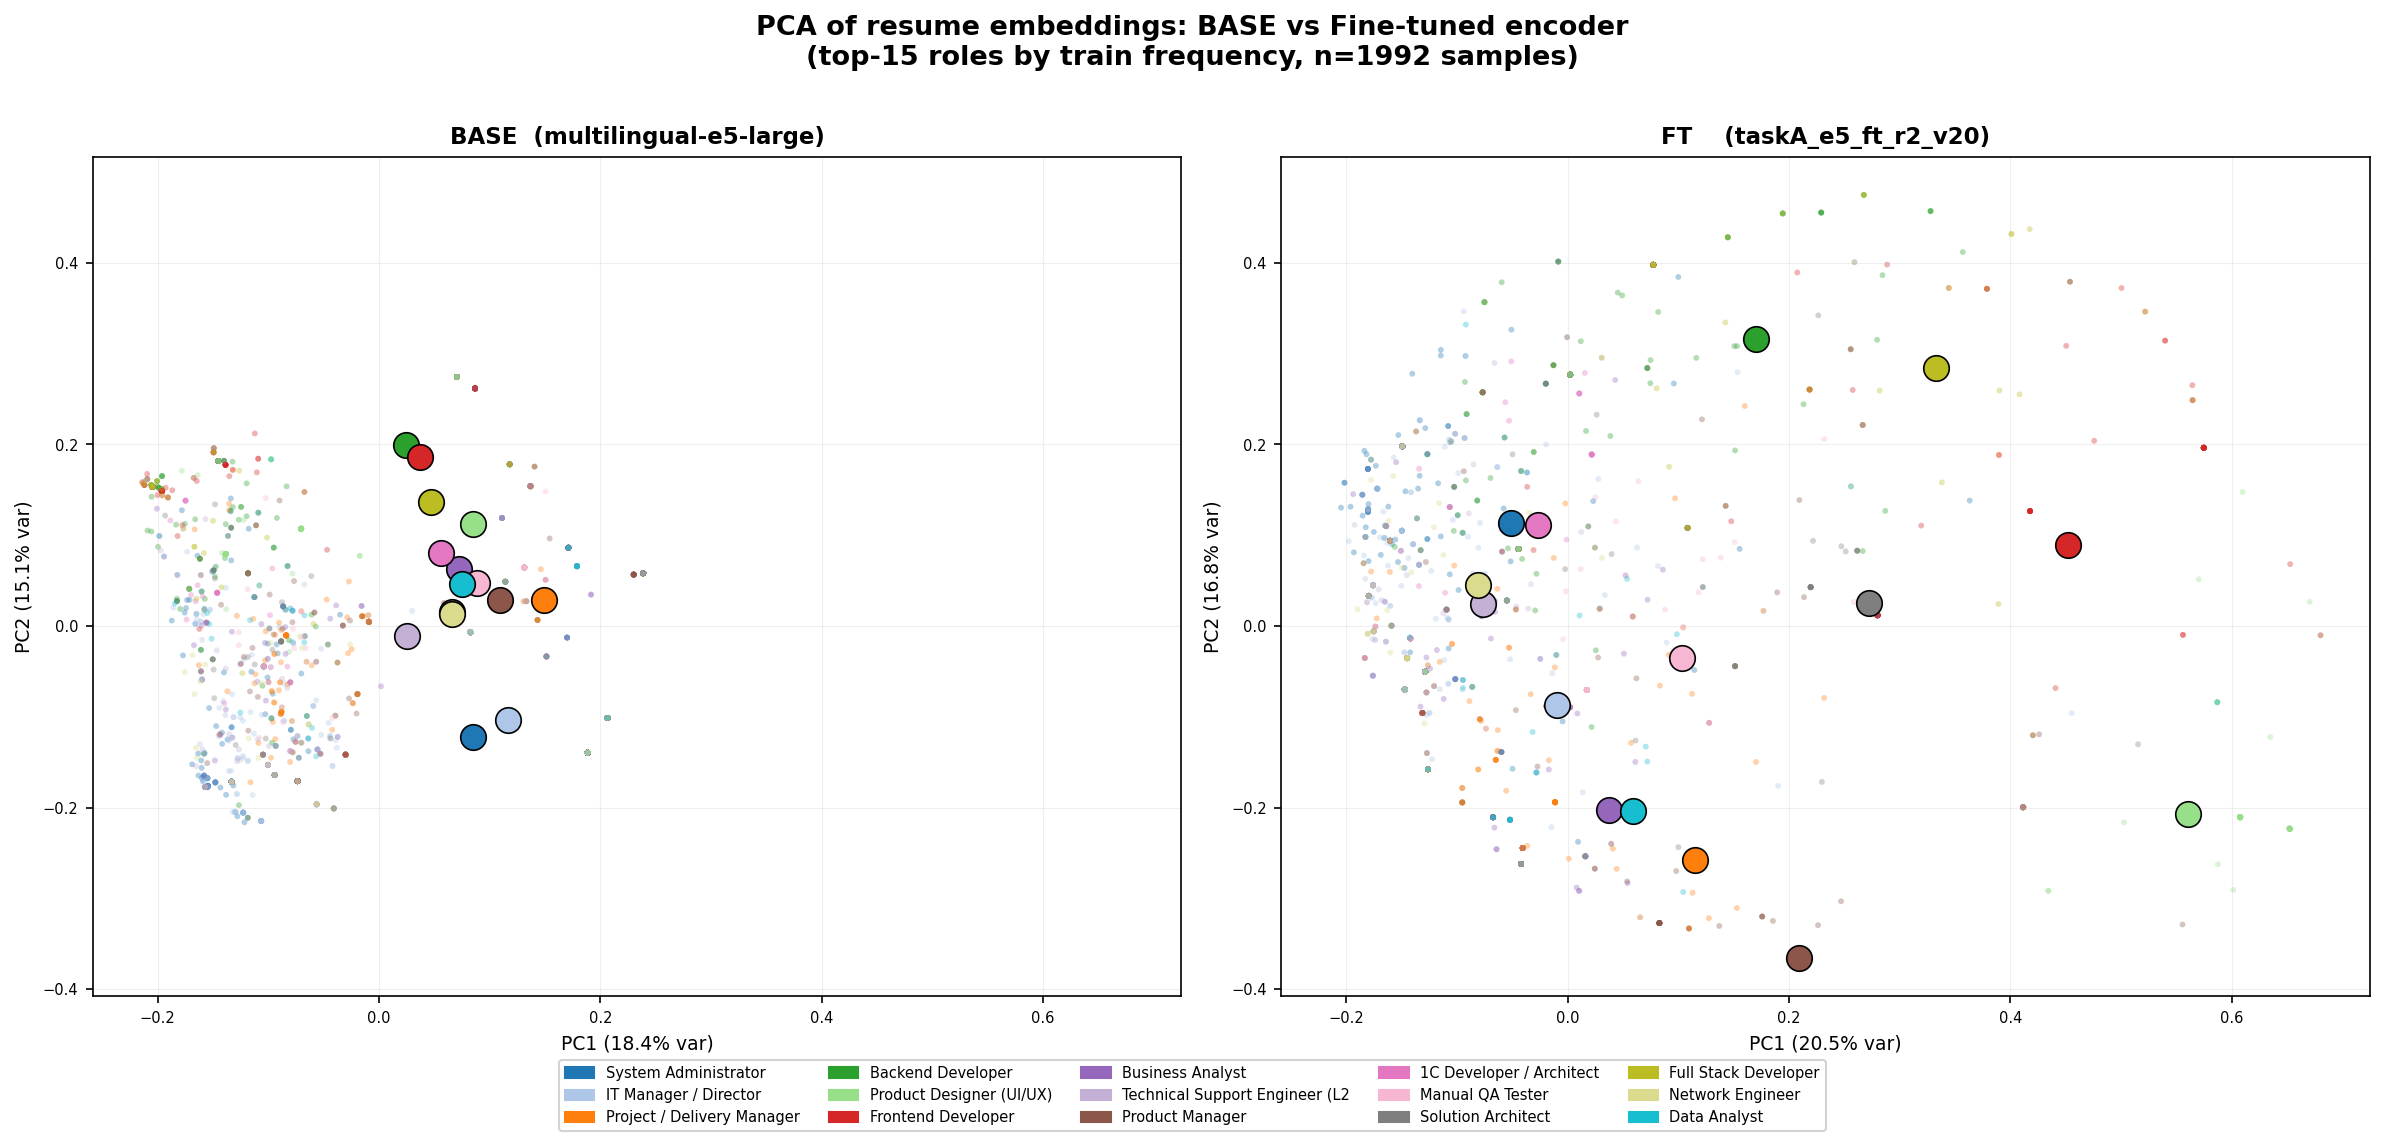

Сохранено: pca_ft_comparison_v2.png

Средняя попарная дистанция между role-центроидами:
  BASE: 0.4254
  FT:   0.7822  (Δ = +0.3568, +83.9%)


In [ ]:


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

TOP_K_ROLES  = 15
N_SAMPLES    = 2000
PCA_SEED     = 42
FIG_DPI      = 150
SAVE_PATH    = "pca_ft_comparison_v2.png"

# ── 1. Выборка (без изменений) ────────────────────────────────────────────────
freq_in_train = [(i, np.sum(y_tr_A == i)) for i in range(VOCAB_A)]
freq_in_train.sort(key=lambda x: -x[1])
top_role_ids = [rid for rid, _ in freq_in_train[:TOP_K_ROLES]]
top_role_set = set(top_role_ids)

mask_top = np.array([y_tr_A[j] in top_role_set for j in range(len(idx_tr_A))])
idx_top  = idx_tr_A[mask_top]
y_top    = y_tr_A[mask_top]

rng = np.random.default_rng(PCA_SEED)
if len(idx_top) > N_SAMPLES:
    chosen = []
    for rid in top_role_ids:
        where  = np.where(y_top == rid)[0]
        n_take = max(1, int(N_SAMPLES * len(where) / len(idx_top)))
        chosen.extend(rng.choice(where, size=min(n_take, len(where)), replace=False).tolist())
    chosen = np.array(chosen)
else:
    chosen = np.arange(len(idx_top))

idx_viz = idx_top[chosen]
y_viz   = y_top[chosen]
print(f"Точек для визуализации: {len(idx_viz)}, ролей: {TOP_K_ROLES}")

# ── 2. Эмбеддинги (без изменений) ────────────────────────────────────────────
texts_viz      = [docs_titles_A[i] for i in idx_viz]
role_texts_pca = [build_doc_occ(all_roles_A[rid]) for rid in top_role_ids]

print("Кодирую BASE ...")
st_base_pca       = SentenceTransformer(MODEL_NAME, device=str(device))
emb_base          = st_base_pca.encode(texts_viz, batch_size=32,
                                        normalize_embeddings=True,
                                        show_progress_bar=True).astype(np.float32)
role_emb_base_pca = st_base_pca.encode(role_texts_pca, batch_size=32,
                                        normalize_embeddings=True).astype(np.float32)
st_base_pca.to("cpu"); _gc()

print("Кодирую FT ...")
st_ft_pca       = SentenceTransformer(CKPT_FT_A_R2, device=str(device))
emb_ft          = st_ft_pca.encode(texts_viz, batch_size=32,
                                    normalize_embeddings=True,
                                    show_progress_bar=True).astype(np.float32)
role_emb_ft_pca = st_ft_pca.encode(role_texts_pca, batch_size=32,
                                    normalize_embeddings=True).astype(np.float32)
st_ft_pca.to("cpu"); _gc()

# ── 3. Два отдельных PCA ──────────────────────────────────────────────────────
pca_base = PCA(n_components=2, random_state=PCA_SEED)
pca_base.fit(np.vstack([emb_base, role_emb_base_pca]))
proj_base      = pca_base.transform(emb_base)
proj_role_base = pca_base.transform(role_emb_base_pca)
var1_b, var2_b = pca_base.explained_variance_ratio_ * 100

pca_ft = PCA(n_components=2, random_state=PCA_SEED)
pca_ft.fit(np.vstack([emb_ft, role_emb_ft_pca]))
proj_ft      = pca_ft.transform(emb_ft)
proj_role_ft = pca_ft.transform(role_emb_ft_pca)
var1_f, var2_f = pca_ft.explained_variance_ratio_ * 100

# ── 4. Одинаковый масштаб: общий диапазон по обоим наборам точек ──────────────
all_proj = np.vstack([proj_base, proj_ft, proj_role_base, proj_role_ft])
margin   = 0.05
x_min, x_max = all_proj[:, 0].min(), all_proj[:, 0].max()
y_min, y_max = all_proj[:, 1].min(), all_proj[:, 1].max()
x_pad = (x_max - x_min) * margin
y_pad = (y_max - y_min) * margin
xlim  = (x_min - x_pad, x_max + x_pad)
ylim  = (y_min - y_pad, y_max + y_pad)

# ── 5. Цвета ──────────────────────────────────────────────────────────────────
cmap   = matplotlib.colormaps.get_cmap("tab20")
colors = {rid: cmap(k / TOP_K_ROLES) for k, rid in enumerate(top_role_ids)}
pt_colors = [colors[y] for y in y_viz]

# ── 6. Рисуем ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=FIG_DPI)
fig.suptitle(
    f"PCA of resume embeddings: BASE vs Fine-tuned encoder\n"
    f"(top-{TOP_K_ROLES} roles by train frequency, n={len(idx_viz)} samples)",
    fontsize=13, fontweight="bold", y=1.01
)

panels = [
    (axes[0], proj_base, proj_role_base,
     f"BASE  ({MODEL_NAME.split('/')[-1]})", var1_b, var2_b),
    (axes[1], proj_ft,   proj_role_ft,
     f"FT    ({CKPT_FT_A_R2})",              var1_f, var2_f),
]

for ax, proj, proj_role, title_tag, v1, v2 in panels:
    ax.scatter(proj[:, 0], proj[:, 1],
               c=pt_colors, s=8, alpha=0.35, linewidths=0)

    # Центроиды — крупные, без подписей
    for k, rid in enumerate(top_role_ids):
        cx, cy = proj_role[k]
        ax.scatter(cx, cy, marker="o", s=150, c=[colors[rid]],
                   edgecolors="black", linewidths=0.8, zorder=5)
 

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title_tag, fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC1 ({v1:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({v2:.1f}% var)", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2, linewidth=0.5)
patches = [mpatches.Patch(color=colors[rid], label=all_roles_A[rid][:30])
           for rid in top_role_ids]
fig.legend(handles=patches, loc="lower center", ncol=5,
           fontsize=7, framealpha=0.85,
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"Сохранено: {SAVE_PATH}")

# ── 7. Метрика (в исходном пространстве, не в PCA) ───────────────────────────
def mean_inter_centroid_dist(role_embs):
    n = len(role_embs)
    dists = [np.linalg.norm(role_embs[i] - role_embs[j])
             for i in range(n) for j in range(i+1, n)]
    return np.mean(dists)

d_base = mean_inter_centroid_dist(role_emb_base_pca)
d_ft   = mean_inter_centroid_dist(role_emb_ft_pca)
print(f"\nСредняя попарная дистанция между role-центроидами:")
print(f"  BASE: {d_base:.4f}")
print(f"  FT:   {d_ft:.4f}  (Δ = {d_ft - d_base:+.4f}, {(d_ft/d_base - 1)*100:+.1f}%)")

In [ ]:


CKPT_FT_V19   = "taskA_e5_ft_r2_v19" 
CKPT_BASE_V19 = "taskA_embeddings_BASE_v19_cmp.npz"  # кэш BASE эмбеддингов

# ── 1. BASE эмбеддинги (с кэшем) ─────────────────────────────────────────────
def _load_base_cache_v19(path):
    if not os.path.isfile(path):
        return None
    try:
        data = np.load(path, allow_pickle=False)
        required = {"X_seq_base", "X_doc_base", "X_skills_base",
                    "X_about_base", "role_emb_base"}
        if not required.issubset(data.files):
            print("Кэш неполный — пересчитываю.")
            return None
        return dict(data)
    except Exception:
        os.remove(path)
        return None

base_feats_v19 = _load_base_cache_v19(CKPT_BASE_V19)

if base_feats_v19 is None:
    print("Кодирую BASE эмбеддинги ...")
    st_base_v19 = SentenceTransformer(MODEL_NAME, device=str(device))

    def enc_b(texts, bs=32):
        safe = [t if t is not None else "query: [empty]" for t in texts]
        return st_base_v19.encode(safe, batch_size=bs,
                                  normalize_embeddings=True,
                                  show_progress_bar=True).astype(np.float32)

    def _skills_text(row):
        s = str(row.get("skills", "") or "").strip()
        return ("query: skills: " + s) if s else "query: skills: [empty]"

    def _about_text(row):
        a = str(row.get("about", "") or "").strip()
        return ("query: about: " + a[:500]) if a else "query: about: [empty]"

    role_texts_b     = [build_doc_occ(r) for r in all_roles_A]
    role_emb_base_np = st_base_v19.encode(role_texts_b, batch_size=32,
                                           normalize_embeddings=True,
                                           show_progress_bar=False).astype(np.float32)
    X_seq_base   = enc_b(docs_titles_A, bs=32)
    X_doc_base   = enc_b(docs_desc_A,   bs=16)
    X_skills_base = enc_b([_skills_text(df_A.iloc[i]) for i in range(N_A)], bs=16)
    X_about_base  = enc_b([_about_text(df_A.iloc[i])  for i in range(N_A)], bs=16)

    st_base_v19.to("cpu"); _gc()
    np.savez_compressed(CKPT_BASE_V19,
        X_seq_base=X_seq_base, X_doc_base=X_doc_base,
        X_skills_base=X_skills_base, X_about_base=X_about_base,
        role_emb_base=role_emb_base_np)
    base_feats_v19 = dict(np.load(CKPT_BASE_V19, allow_pickle=False))
    print("BASE сохранён: " + CKPT_BASE_V19)
else:
    print("BASE загружен из кэша: " + CKPT_BASE_V19)

role_emb_base_v19 = torch.tensor(base_feats_v19["role_emb_base"]).float()

# ── 2. FT v19 эмбеддинги ──────────────────────────────────────────────────────
CKPT_FT_V19_EMB = "taskA_embeddings_FT_v19_cmp.npz"

def _load_ft_cache_v19(path):
    if not os.path.isfile(path):
        return None
    try:
        data = np.load(path, allow_pickle=False)
        required = {"X_seq_ft", "X_doc_ft", "X_skills_ft",
                    "X_about_ft", "role_emb_ft"}
        if not required.issubset(data.files):
            print("FT кэш неполный — пересчитываю.")
            return None
        return dict(data)
    except Exception:
        os.remove(path)
        return None

ft_feats_v19 = _load_ft_cache_v19(CKPT_FT_V19_EMB)

if ft_feats_v19 is None:
    print("Кодирую FT v19 эмбеддинги через " + CKPT_FT_V19 + " ...")
    st_ft_v19 = SentenceTransformer(CKPT_FT_V19, device=str(device))

    def enc_ft(texts, bs=32):
        safe = [t if t is not None else "query: [empty]" for t in texts]
        return st_ft_v19.encode(safe, batch_size=bs,
                                normalize_embeddings=True,
                                show_progress_bar=True).astype(np.float32)

    def _skills_text_ft(row):
        s = str(row.get("skills", "") or "").strip()
        return ("query: skills: " + s) if s else "query: skills: [empty]"

    def _about_text_ft(row):
        a = str(row.get("about", "") or "").strip()
        return ("query: about: " + a[:500]) if a else "query: about: [empty]"

    role_texts_ft     = [build_doc_occ(r) for r in all_roles_A]
    role_emb_ft_np    = st_ft_v19.encode(role_texts_ft, batch_size=32,
                                          normalize_embeddings=True,
                                          show_progress_bar=False).astype(np.float32)
    X_seq_ft    = enc_ft(docs_titles_A, bs=32)
    X_doc_ft    = enc_ft(docs_desc_A,   bs=16)
    X_skills_ft = enc_ft([_skills_text_ft(df_A.iloc[i]) for i in range(N_A)], bs=16)
    X_about_ft  = enc_ft([_about_text_ft(df_A.iloc[i])  for i in range(N_A)], bs=16)

    st_ft_v19.to("cpu"); _gc()
    np.savez_compressed(CKPT_FT_V19_EMB,
        X_seq_ft=X_seq_ft, X_doc_ft=X_doc_ft,
        X_skills_ft=X_skills_ft, X_about_ft=X_about_ft,
        role_emb_ft=role_emb_ft_np)
    ft_feats_v19 = dict(np.load(CKPT_FT_V19_EMB, allow_pickle=False))
    print("FT v19 эмбеддинги сохранены: " + CKPT_FT_V19_EMB)
else:
    print("FT v19 загружен из кэша: " + CKPT_FT_V19_EMB)

role_emb_ft_v19 = torch.tensor(ft_feats_v19["role_emb_ft"]).float()

# ── 3. Конфигурации ───────────────────────────────────────────────────────────
def _cat(*arrays):
    return np.concatenate(arrays, axis=1).astype(np.float32)

FT_V19_CONFIGS = [
    (
        "seq (titles only)",
        _cat(ft_feats_v19["X_seq_ft"]),   role_emb_ft_v19,
        _cat(base_feats_v19["X_seq_base"]), role_emb_base_v19,
    ),
    (
        "doc (titles+desc)",
        _cat(ft_feats_v19["X_doc_ft"]),   role_emb_ft_v19,
        _cat(base_feats_v19["X_doc_base"]), role_emb_base_v19,
    ),
    (
        "skills_emb only",
        _cat(ft_feats_v19["X_skills_ft"]),   role_emb_ft_v19,
        _cat(base_feats_v19["X_skills_base"]), role_emb_base_v19,
    ),
    (
        "about_emb only",
        _cat(ft_feats_v19["X_about_ft"]),   role_emb_ft_v19,
        _cat(base_feats_v19["X_about_base"]), role_emb_base_v19,
    ),
    (
        "D2 full (doc+skills+about+struct)",
        _cat(ft_feats_v19["X_doc_ft"], ft_feats_v19["X_skills_ft"],
             ft_feats_v19["X_about_ft"],
             X_career_A_sc, X_location_A_sc, X_edu_A_sc),
        role_emb_ft_v19,
        _cat(base_feats_v19["X_doc_base"], base_feats_v19["X_skills_base"],
             base_feats_v19["X_about_base"],
             X_career_A_sc, X_location_A_sc, X_edu_A_sc),
        role_emb_base_v19,
    ),
]

# ── 4. Обучение и сравнение ───────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ENCODER ABLATION v19: FT (" + CKPT_FT_V19 + ")  vs  BASE (" + MODEL_NAME + ")")
print("Протокол: CareerMLP_Additive x " + str(N_SEEDS_ABL) + " seeds " + str(ABL_SEEDS))
print("=" * 80)

ft_v19_results = {}

for cfg_name, X_ft, re_ft, X_base, re_base in FT_V19_CONFIGS:
    print("\n-- " + cfg_name + "  [dim_ft=" + str(X_ft.shape[1]) + "] --")
    res_ft   = {"MRR": [], "R@1": [], "R@3": []}
    res_base = {"MRR": [], "R@1": [], "R@3": []}

    for seed in ABL_SEEDS:
        for tag, X_cfg, re_tensor, res_acc in [
            ("FT",   X_ft,   re_ft,   res_ft),
            ("BASE", X_base, re_base, res_base),
        ]:
            torch.manual_seed(seed)
            model = CareerMLP_Additive(X_cfg.shape[1],
                                       emb_dim=EMB_DIM,
                                       vocab_size=VOCAB_A).to(device)
            model = train_mlp(model,
                              X_cfg[idx_tr_A], y_tr_A,
                              X_cfg[idx_vl_A], y_vl_A,
                              re_tensor)
            sc_te = predict_mlp(model, X_cfg[idx_te_A], re_tensor)
            r = eval_full(sc_te, y_te_A)
            res_acc["MRR"].append(r["MRR"])
            res_acc["R@1"].append(r["R@1"])
            res_acc["R@3"].append(r["R@3"])
            print("  " + tag + " seed=" + str(seed) + ":"
                  + " MRR=" + str(round(r["MRR"] * 100, 2)) + "%"
                  + "  R@1=" + str(round(r["R@1"] * 100, 2)) + "%"
                  + "  R@3=" + str(round(r["R@3"] * 100, 2)) + "%")
            del model; _gc()

    mrr_ft    = np.mean(res_ft["MRR"]);  mrr_base = np.mean(res_base["MRR"])
    r1_ft     = np.mean(res_ft["R@1"]); r1_base  = np.mean(res_base["R@1"])
    delta_mrr = (mrr_ft - mrr_base) * 100
    delta_r1  = (r1_ft  - r1_base)  * 100

    diffs_r1 = np.array(res_ft["R@1"]) - np.array(res_base["R@1"])
    rng_bt   = np.random.default_rng(BOOTSTRAP_SEED)
    bt_means = [np.mean(rng_bt.choice(diffs_r1, size=len(diffs_r1), replace=True))
                for _ in range(N_BOOTSTRAP)]
    p_val = np.mean(np.array(bt_means) <= 0)

    ft_v19_results[cfg_name] = {
        "MRR_ft": mrr_ft, "MRR_base": mrr_base, "dMRR": delta_mrr,
        "R1_ft":  r1_ft,  "R1_base":  r1_base,  "dR1":  delta_r1,
        "p_boot": p_val,
    }

    sign = "[+]" if delta_mrr > 0.3 else ("[~]" if delta_mrr > 0 else "[-]")
    print("\n  " + sign
          + "  dMRR=" + str(round(delta_mrr, 2)) + "pp"
          + "  dR@1=" + str(round(delta_r1, 2)) + "pp"
          + "  p(FT>BASE)=" + str(round(1 - p_val, 3)))

# ── 5. Итоговая таблица ───────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ИТОГ: FT_v19 (titles+desc) vs BASE")
print("=" * 80)
header = ("  " + "Признак".ljust(35)
          + "MRR_FT".rjust(8) + "MRR_BASE".rjust(10)
          + "dMRR".rjust(8)   + "dR@1".rjust(8)
          + "p(FT>BASE)".rjust(12) + "  Вывод")
print(header)
print("-" * 80)
for cfg_name, v in ft_v19_results.items():
    p_pos   = 1 - v["p_boot"]
    verdict = ("значим"   if p_pos > 0.95 and v["dMRR"] > 0.3
               else "незначим" if abs(v["dMRR"]) < 0.3
               else "хуже"     if v["dMRR"] < 0
               else "слабый")
    row = ("  " + cfg_name.ljust(35)
           + str(round(v["MRR_ft"] * 100, 2)).rjust(7) + "%"
           + str(round(v["MRR_base"] * 100, 2)).rjust(9) + "%"
           + (("+" if v["dMRR"] >= 0 else "") + str(round(v["dMRR"], 2)) + "pp").rjust(9)
           + (("+" if v["dR1"]  >= 0 else "") + str(round(v["dR1"],  2)) + "pp").rjust(9)
           + str(round(p_pos, 3)).rjust(12)
           + "  " + verdict)
    print(row)
print("=" * 80)

BASE загружен из кэша: taskA_embeddings_BASE_v19_cmp.npz
FT v19 загружен из кэша: taskA_embeddings_FT_v19_cmp.npz

ENCODER ABLATION v19: FT (taskA_e5_ft_r2_v19)  vs  BASE (intfloat/multilingual-e5-large)
Протокол: CareerMLP_Additive x 3 seeds [42, 123, 777]

-- seq (titles only)  [dim_ft=1024] --


  FT seed=42: MRR=66.79%  R@1=53.09%  R@3=76.18%
  BASE seed=42: MRR=66.67%  R@1=52.89%  R@3=76.22%
  FT seed=123: MRR=66.86%  R@1=53.13%  R@3=76.35%
  BASE seed=123: MRR=66.66%  R@1=52.8%  R@3=76.46%
  FT seed=777: MRR=66.82%  R@1=53.08%  R@3=76.34%
  BASE seed=777: MRR=66.64%  R@1=52.83%  R@3=76.2%

  [~]  dMRR=0.16pp  dR@1=0.26pp  p(FT>BASE)=1.0

-- doc (titles+desc)  [dim_ft=1024] --
  FT seed=42: MRR=71.48%  R@1=57.99%  R@3=82.04%
  BASE seed=42: MRR=69.75%  R@1=55.73%  R@3=80.64%
  FT seed=123: MRR=71.3%  R@1=57.64%  R@3=82.04%
  BASE seed=123: MRR=69.78%  R@1=55.68%  R@3=80.75%
  FT seed=777: MRR=71.44%  R@1=57.9%  R@3=82.07%
  BASE seed=777: MRR=69.84%  R@1=55.92%  R@3=80.75%

  [+]  dMRR=1.62pp  dR@1=2.06pp  p(FT>BASE)=1.0

-- skills_emb only  [dim_ft=1024] --
  FT seed=42: MRR=62.0%  R@1=46.52%  R@3=72.56%
  BASE seed=42: MRR=61.85%  R@1=46.59%  R@3=72.1%
  FT seed=123: MRR=62.02%  R@1=46.57%  R@3=72.78%
  BASE seed=123: MRR=61.78%  R@1=46.49%  R@3=72.11%
  FT seed=777: MRR=6